<div style="
    position: relative;
    width: 100%;
    min-height: 520px;
    border-radius: 10px;
    overflow: hidden;
">

  <!-- Use img instead of background-image -->
  <img src="goldenGatebrge.png"
       alt="Golden Gate Bridge"
       style="width: 100%; height: auto; display: block;">

  <!-- Dark overlay -->
  <div style="
      position: absolute;
      top: 0; left: 0; right: 0; bottom: 0;
      background-color: rgba(0,0,0,0.45);
  "></div>

  <!-- Your centered title block (unchanged) -->
  <div style="
      position: absolute;
      top: 30%;
      left: 50%;
      transform: translate(-50%, -50%);
      width: 90%;
      max-width: 900px;
      text-align: center;
      color: white;
      z-index: 2;
  ">
      <div style="font-size: 42px; font-weight: 800; line-height: 1.15;">
          San Francisco Crime Analysis (2018-2025)
      </div>
      <div style="margin-top: 10px; font-size: 22px; font-weight: 500;">
          Forecasting, Neighborhood Patterns, and Patrol Optimization Using Python
      </div>
  </div>

  <!-- Author box (your code) -->
  <div style="
    position: absolute;
    bottom: 40px;
    left: 40px;
    z-index: 2;
    color: white;
    font-size: 15px;
    line-height: 1.45;
    background-color: rgba(0,0,0,0.45);
    padding: 12px 20px;
    border-radius: 6px;
    width: auto;
    max-width: none;
    text-align: left;
    white-space: nowrap;
  ">
    <strong>Author:</strong> Sileshi Hirpa<br>
    <strong>Course:</strong> DAT 301 (Exploring Data in R &amp; Python)<br>
    <strong>Project:</strong> Project 2 (Python)<br>
    <strong>Professor:</strong> Dr. Neha Joshi (PhD)<br>
    <strong>Data Source:</strong> SFPD Incident Reports (DataSF)<br>
    <strong>Time Window:</strong> 2018–2025
  </div>

  <!-- Footer text (unchanged) -->
  <div style="
      position: absolute;
      bottom: 40px;
      right: 40px;
      z-index: 2;
      color: white;
      font-size: 14px;
      font-style: italic;
      text-align: right;
  ">
      Arizona State University • December 2025
  </div>
</div>

<div style="text-align: center; font-size: 12px; color: gray; margin-top: 6px;">
    Cover Image Source: Britannica - “Golden Gate Bridge”
</div>


# **Table of Contents**

1. **Introduction**  
   - [1.1 City Context: San Francisco in Brief](#city-context)  
   - [1.2 Motivation for This Project](#motivation)

2. **Dataset**  
   - [2.1 About the Dataset](#about-the-dataset)  
   - [2.2 Load CSV File and Initial Cleaning](#initial-cleaning)  
     - [2.2.1 Summary of Missing-Value Decisions (Before EDA)](#summary-of-missing-values)  
   - [2.3 Distribution of Key Categorical Variables](#categorical-distribution-pre)  
   - [2.4 Spatial Density Check (Hexbin Map)](#spatial-density)  
   - [2.5 Understanding the Official Neighborhood Naming System](#neighborhood-naming)  
   - [2.6 Pre-EDA Summary](#pre-eda-summary)

3. **Exploratory Data Analysis (EDA)**  
   - [3.1 Yearly Trends](#yearly-trends)  
   - [3.2 Monthly Trend Visualization](#monthly-trend)  
   - [3.3 Weekday Patterns](#weekday-patterns)  
   - [3.4 Hour-of-Day Patterns](#hour-patterns)  
   - [3.5 Crime Category Distribution](#category-distribution)  
   - [3.6 Neighborhood Distribution](#neighborhood-distribution)  
   - [3.7 Time-of-Day vs Crime Category (Heatmap)](#tod-category-heatmap)  
   - [3.8 Neighborhood × Category Matrix](#neighborhood-category-matrix)  
   - [3.9 Year-Month Trend by Category](#year-month-category)  
   - [3.10 Summary of Key EDA Findings](#eda-summary)

4. **Neighborhood-Level Analysis**  
   - [4.0 Introduction and Purpose](#neighborhood-purpose)  
   - [4.1 Ranking Neighborhoods](#ranking-neighborhoods)  
   - [4.2 Neighborhood Time Series (Long-Term Trends)](#neighborhood-time-series)  
   - [4.3 Choropleth Map: Crime Distribution Across All 41 Neighborhoods](#choropleth-map)  
   - [4.4 Crime Type by Neighborhood (Heatmap)](#neighborhood-heatmap)  
   - [4.5 Neighborhood Safety Scorecard (Visitor-Friendly Summary)](#safety-scorecard)

5. **Forecasting: 2026 Outlook**  
   - [5.1 Goal of This Section](#forecast-goal)  
   - [5.2 Visual Check of the Time Series and Model Deployment](#model-check)  
   - [5.3 Forecast (Next 12 Months)](#forecast-next-12)

6. **Results and Interpretation**  
   - [6.0 Summary and Insights](#results)

7. **Dashboard Development: From Benchmark to Deployment**  
   - [7.1 Benchmark: Official SFPD Crime Dashboard](#benchmark)  
   - [7.2 Full Analytical Dashboard (2018–2025 Complete Dataset)](#dashboard-full)  
   - [7.3 Streamlit Deployment (API-Fetched Dataset)](#dashboard-live)  
   - [7.4 Operational Value: Patrol Optimization & Incident Mitigation](#patrol)

8. **References**  
   - [Reference List](#references)


## 1. Introduction <a id="introduction"></a>


### 1.1 City Context: San Francisco in Brief <a id="city-context"></a>

San Francisco is a compact and intensely populated city of 808,988 residents across only 46.7 square miles, with a density of more than 17,300 people per square mile (U.S. Census Bureau, 2023; Census Reporter, ACS 2023). Its population rises above 1.1 million on weekdays as commuters, students, and visitors enter the city, creating sustained activity across downtown corridors and transit hubs. Tourism remains central to the local economy, with more than 23 million annual visitors (San Francisco Travel Association, 2024) concentrated in areas such as Fisherman’s Wharf, Union Square, Chinatown, SoMa, the Mission, and the Waterfront/Embarcadero.

The city’s geography - anchored by **I-80** to the East Bay, the **Golden Gate Bridge (US-101 North)** to Marin, and **Highway 101/I-280** to the Peninsula - funnels travel through a small number of major entry points that shape both mobility and routine activity patterns. Recurring events such as Pride, Fleet Week, Outside Lands, Bay to Breakers, Dreamforce, and year-round games at Oracle Park and Chase Center generate substantial temporary population surges. Together, these structural and mobility dynamics help explain why neighborhoods such as the Tenderloin, South of Market, and the Mission record consistently high incident counts in the 2018-2025 period.

The screenshot below provides a simple geographic orientation for readers unfamiliar with the city and highlights the major entrances and exits:




<div style="text-align: center;">
    <img src="SF_borders.png" width="550">
    <p><strong>Figure 1.</strong> Outline of San Francisco’s city limits, with the eastern shoreline along San Francisco Bay, the northern edge overlooking the Golden Gate area, and the southern boundary leading toward Daly City and the Peninsula.</p>
    <p style="font-size: 12px; color: gray;">Source: Google Maps (screenshot by the author)</p>
</div>



### 1.2 Motivation for This Project <a id="motivation"></a>

For the past several years, I have worked as an Uber driver in the San Francisco Bay Area. Many passengers - mostly visitors alike - frequently ask similar questions:

- “Which neighborhoods are safe to stay in?”  
- “Are there areas we should avoid late at night?”  
- “Which areas do you recommend for best experience?”  

I also meet many visitors who are excited about finding good hotel deals online, but later realize they did not have enough information about where those hotels are located or how the surrounding neighborhoods differ. That lack of context can lead to confusion or discomfort, especially when people arrive late at night near areas such as the Tenderloin or parts of SoMa. On several occasions, riders have even mentioned changing their hotel reservations after arriving in the city because the neighborhood they originally booked did not feel as pleasant or welcoming as they expected.

This project uses open data from the San Francisco Police Department to explore the following questions:

1. **Where** are incidents most concentrated across neighborhoods?  
2. **When** do incidents peak across hours and days of the week?  
3. **How** have incident levels changed from 2018 through 2025?  
4. **What** short-term forecast can help visualize early 2026 trends?  

This analysis serves two purposes:  
- to inform my own understanding as someone who moves throughout the city daily  
- and to demonstrate how open-source crime data can be transformed into meaningful insights through Python, visualization, and forecasting methods.

The next sections begin the data loading, cleaning, and exploratory analysis workflow, but first the necessary libraries are loaded as follows.


In [1]:
# =================
# Import libraries
# =================

import pandas as pd
import numpy as np

# Visualization Libraries 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import geopandas as gpd
import folium


# Time-Series Libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA


---

## 2. Dataset <a id="dataset"></a>

### 2.1 About the Dataset <a id="about-the-dataset"></a>

The analysis in this project is based on the *Police Department Incident Reports: 2018 - November 25, 2025* dataset obtained from [DataSF](https://data.sfgov.org/Public-Safety/Police-Department-Incident-Reports-2018-to-Present/wg3w-h783/data_preview), the City and County of San Francisco’s open data portal. The dataset includes all reported police incidents recorded by the San Francisco Police Department (SFPD), along with associated attributes such as the incident category, description, neighborhood, timestamp, and geographic coordinates.

This dataset is well suited for exploring crime trends across time and space because it provides:

- complete coverage of all police-reported incidents,
- detailed timestamps for hourly, daily, and monthly analysis,
- neighborhood information for spatial comparison, and
- latitude and longitude for mapping and geographic visualization.

The dataset used in this project was downloaded on November 21, 2025 and contains nearly one million incident records covering the full 2018-2025 period. The next section loads the dataset and performs initial cleaning steps to prepare it for analysis.


### 2.2 Load CSV File and Initial Cleaning <a id="initial-cleaning"></a>

This code cell performs the following actions:

1. **Loading the dataset** and parsing the date column as a proper datetime object.
2. **Renaming key columns** so that the dataset uses clear and consistent variable names throughout the notebook.
3. **Creating** the `year` **variable** and filters the dataset to the 2018 - 2025 window.
4. **Dropping records missing geographic coordinates**, since latitude and longitude are required for neighborhood mapping and location-based analysis.

In [2]:
# ============================================================
# STEP 1 — Load the raw SFPD dataset (VS Code)
# ============================================================

import os

# Absolute path to the dataset
FULL_CSV_PATH = "/Users/sileshihirpa/Desktop/ASU/2025/3. Fall/Session B/DAT301/Projects/project 2/Police_Department_Incident_Reports__2018_to_Present_20251125.csv"

print("Loading dataset from:", FULL_CSV_PATH)

try:
    df = pd.read_csv(
        FULL_CSV_PATH,
        parse_dates=["Incident Date"],   # Parse date column now
        low_memory=False
    )
    print("✅ Full dataset loaded successfully.")
    print("Shape:", df.shape)

except FileNotFoundError:
    print(f"❌ ERROR: File not found at: {FULL_CSV_PATH}")
    df = pd.DataFrame()


Loading dataset from: /Users/sileshihirpa/Desktop/ASU/2025/3. Fall/Session B/DAT301/Projects/project 2/Police_Department_Incident_Reports__2018_to_Present_20251125.csv
✅ Full dataset loaded successfully.
Shape: (985461, 29)


In [3]:
# ============================================================
# STEP 2 — Rename columns, add 'year', filter years, drop bad geo
#   This is the SAME logic as in your Jupyter notebook
# ============================================================

if df.empty:
    print("❌ DataFrame is empty. Skipping cleaning.")
else:
    # 1) Rename columns to standard names
    df = df.rename(columns={
        "Incident Date": "date",
        "Incident Time": "time",
        "Incident Category": "category",
        "Analysis Neighborhood": "neighborhood",
        "Latitude": "latitude",
        "Longitude": "longitude",
        "Incident Day of Week": "weekday",
        "Incident Year": "incident_year"
    })

    # Ensure weekday is text
    df["weekday"] = df["weekday"].astype(str)

    # Create 'year' from the parsed date
    df["year"] = df["date"].dt.year

    print("After rename + year:", df.shape)

    # 2) Filter to 2018–2025 (same as notebook)
    df_original_count = len(df)
    df = df[(df["year"] >= 2018) & (df["year"] <= 2025)].copy()
    print(f"Records after 2018–2025 filter: {len(df)} (from {df_original_count})")

    # 3) Drop rows without latitude/longitude
    df.dropna(subset=["latitude", "longitude"], inplace=True)
    print(f"Records after dropping missing geo-data: {len(df)}")

    # 4) Environment check for consistency with notebook
    print("\nEnvironment check in VS Code:")
    print("Shape:", df.shape)
    print(df["category"].isna().sum(), "missing categories")
    print(df["category"].value_counts().head(15))


After rename + year: (985461, 30)
Records after 2018–2025 filter: 985461 (from 985461)
Records after dropping missing geo-data: 930829

Environment check in VS Code:
Shape: (930829, 30)
1411 missing categories
category
Larceny Theft          263218
Other Miscellaneous     68001
Malicious Mischief      64795
Assault                 63688
Burglary                54811
Motor Vehicle Theft     53730
Non-Criminal            36523
Fraud                   32117
Warrant                 31823
Drug Offense            29560
Recovered Vehicle       27951
Lost Property           24026
Missing Person          22180
Robbery                 22153
Suspicious Occ          21004
Name: count, dtype: int64


In [4]:
# ============================================================
# STEP 3 — Create incident_datetime and time-based features
#   - Combines 'date' and 'time'
#   - Adds hour, month, weekday, and year_month
# ============================================================

# Quick check of date and time columns
print(df[["date", "time"]].head())

# Combine date + time into one datetime column
df["incident_datetime"] = pd.to_datetime(
    df["date"].dt.strftime("%Y-%m-%d") + " " + df["time"].astype(str),
    errors="coerce"
)

# Hour of day (0–23)
df["hour"] = df["incident_datetime"].dt.hour

# Numerical month (1–12)
df["month"] = df["incident_datetime"].dt.month

# Weekday as a number: Monday=0, Sunday=6
df["weekday_num"] = df["incident_datetime"].dt.weekday

# Full weekday name, e.g. "Monday"
df["weekday_name"] = df["incident_datetime"].dt.day_name()

# "YYYY-MM" string, useful for monthly trend plots
df["year_month"] = df["incident_datetime"].dt.to_period("M").astype(str)

# Inspect a small sample to verify the datetime and hour
print(df[["date", "time", "incident_datetime", "hour"]].head(10))


        date   time
1 2025-08-27  00:37
2 2025-07-17  15:00
3 2025-08-23  21:30
4 2025-08-15  12:00
5 2025-08-15  21:45
         date   time   incident_datetime  hour
1  2025-08-27  00:37 2025-08-27 00:37:00     0
2  2025-07-17  15:00 2025-07-17 15:00:00    15
3  2025-08-23  21:30 2025-08-23 21:30:00    21
4  2025-08-15  12:00 2025-08-15 12:00:00    12
5  2025-08-15  21:45 2025-08-15 21:45:00    21
7  2025-08-24  12:00 2025-08-24 12:00:00    12
8  2025-08-23  16:30 2025-08-23 16:30:00    16
9  2025-08-21  21:55 2025-08-21 21:55:00    21
10 2025-08-26  00:19 2025-08-26 00:19:00     0
11 2025-08-25  22:29 2025-08-25 22:29:00    22


In [5]:
# ============================================================
# STEP 4 — Add broad time-of-day categories
#   Morning / Afternoon / Evening / Night
# ============================================================

# Defines broad parts of the day based on the hour of the incident.
def time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

# Applies the time-of-day categories to each incident based on its hour.
df["time_of_day"] = df["hour"].apply(time_of_day)

# Quick sanity check
print("\nTime of day distribution:")
print(df["time_of_day"].value_counts())
print("\nSample rows with time_of_day:")
print(df[["incident_datetime", "hour", "time_of_day"]].head(10))



Time of day distribution:
time_of_day
Afternoon    264658
Night        248841
Morning      212319
Evening      205011
Name: count, dtype: int64

Sample rows with time_of_day:
     incident_datetime  hour time_of_day
1  2025-08-27 00:37:00     0       Night
2  2025-07-17 15:00:00    15   Afternoon
3  2025-08-23 21:30:00    21       Night
4  2025-08-15 12:00:00    12   Afternoon
5  2025-08-15 21:45:00    21       Night
7  2025-08-24 12:00:00    12   Afternoon
8  2025-08-23 16:30:00    16   Afternoon
9  2025-08-21 21:55:00    21       Night
10 2025-08-26 00:19:00     0       Night
11 2025-08-25 22:29:00    22       Night


In [6]:
# ============================================================
# STEP 5 — Spatial join with neighborhood polygons
#   - Convert incidents to points
#   - Join with neighborhood polygons from GeoJSON
#   - Fill missing 'neighborhood' from polygon name
# ============================================================

import geopandas as gpd
from IPython.display import display  # harmless in VS Code; only used in notebooks

# Safety rename (normally does nothing now, but keeps code robust)
rename_map = {}

if "Latitude" in df.columns and "latitude" not in df.columns:
    rename_map["Latitude"] = "latitude"
if "Longitude" in df.columns and "longitude" not in df.columns:
    rename_map["Longitude"] = "longitude"
if "Analysis Neighborhood" in df.columns and "neighborhood" not in df.columns:
    rename_map["Analysis Neighborhood"] = "neighborhood"

if rename_map:
    df = df.rename(columns=rename_map)

# Final check: ensure we have lowercase latitude/longitude
required_cols = {"latitude", "longitude"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(
        f"Missing expected coordinate columns: {missing}. "
        f"Available columns: {list(df.columns)}"
    )

# Path to the GeoJSON file of analysis neighborhoods
geojson_path = "Analysis_Neighborhoods_20251125.geojson"

# Load the neighborhood polygon layer
gdf = gpd.read_file(geojson_path)

print("Polygon layer loaded:")
print("  Shape:", gdf.shape)
print("  Columns:", list(gdf.columns))

# If you're in a notebook, this will show a preview; in VS Code it just does nothing visible.
try:
    display(gdf.head())
except NameError:
    pass

# Convert the incident dataframe to a GeoDataFrame of points
points = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

# Keep geometry and the neighborhood name column from the polygon layer
gdf_poly = gdf[["geometry", "nhood"]].rename(
    columns={"nhood": "neighborhood_poly"}
)

# Spatial join: assign polygon neighborhood to each incident point
joined = gpd.sjoin(
    points,
    gdf_poly,
    how="left",
    predicate="within"   # use op="within" for older GeoPandas versions
)

# Count missing neighborhoods before repair
before_fill = joined["neighborhood"].isna().sum()

# Fill missing 'neighborhood' values from 'neighborhood_poly'
joined["neighborhood"] = joined["neighborhood"].fillna(joined["neighborhood_poly"])

after_fill = joined["neighborhood"].isna().sum()

print("\nNeighborhood repair summary:")
print(f"  Missing before repair: {before_fill}")
print(f"  Missing after repair:  {after_fill}")

# Drop helper columns created by the join
joined = joined.drop(columns=["neighborhood_poly", "index_right"], errors="ignore")

# Final cleaned dataset for analysis and mapping
df_clean = joined

print("\nFinal cleaned dataset ready:")
print("  Shape:", df_clean.shape)

print("\nTop 10 neighborhoods after repair:")
print(df_clean["neighborhood"].value_counts().head(10))

# In a notebook, this shows a preview; in VS Code it's optional.
try:
    display(df_clean.head())
except NameError:
    pass


Polygon layer loaded:
  Shape: (41, 6)
  Columns: [':id', ':version', ':created_at', ':updated_at', 'nhood', 'geometry']


,:id,:version,:created_at,:updated_at,nhood,geometry
0,row-kat6_uieb_3jtd,rv-dbu2~hpud.6yya,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213..."
1,row-z3d4_b3is_mfk7,rv-zi62-zgjg-kwse,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605..."
2,row-xwem-yyxg.b4xp,rv-n2ba~749k.nkaj,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,Visitacion Valley,"MULTIPOLYGON (((-122.40385 37.71883, -122.4035..."
3,row-cyst-jf3k~s9cp,rv-emkr.suep.757p,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,Twin Peaks,"MULTIPOLYGON (((-122.44695 37.75655, -122.4459..."
4,row-zga5_xbxp_wavz,rv-dhre.4pg3-htj9,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,South of Market,"MULTIPOLYGON (((-122.40371 37.78404, -122.4027..."



Neighborhood repair summary:
  Missing before repair: 292
  Missing after repair:  292

Final cleaned dataset ready:
  Shape: (930829, 38)

Top 10 neighborhoods after repair:
neighborhood
Mission                           101511
Tenderloin                         98456
South of Market                    88164
Financial District/South Beach     63449
Bayview Hunters Point              59899
Western Addition                   32655
North Beach                        28713
Sunset/Parkside                    27796
Nob Hill                           26658
Marina                             26018
Name: count, dtype: int64


,Row ID,Incident Datetime,date,time,incident_year,weekday,Report Datetime,Incident ID,Incident Number,CAD Number,...,data_loaded_at,year,incident_datetime,hour,month,weekday_num,weekday_name,year_month,time_of_day,geometry
1,150752104134,2025/08/27 12:37:00 AM,2025-08-27,00:37,2025,Wednesday,2025/08/27 12:37:00 AM,1507521,250479881,252390049.0,...,2025/08/29 09:53:03 AM,2025,2025-08-27 00:37:00,0,8,2,Wednesday,2025-08,Night,POINT (-122.44901 37.78041)
2,150762309027,2025/07/17 03:00:00 PM,2025-07-17,15:00,2025,Thursday,2025/08/27 11:55:00 AM,1507623,250480775,252391585.0,...,2025/08/29 09:53:03 AM,2025,2025-07-17 15:00:00,15,7,3,Thursday,2025-07,Afternoon,POINT (-122.45135 37.77518)
3,150740506244,2025/08/23 09:30:00 PM,2025-08-23,21:30,2025,Saturday,2025/08/24 02:53:00 PM,1507405,256091227,NaN,...,2025/08/28 09:53:00 AM,2025,2025-08-23 21:30:00,21,8,5,Saturday,2025-08,Night,POINT (-122.4225 37.77455)
4,150723571000,2025/08/15 12:00:00 PM,2025-08-15,12:00,2025,Friday,2025/08/24 07:10:00 PM,1507235,256090348,NaN,...,2025/08/28 09:53:00 AM,2025,2025-08-15 12:00:00,12,8,4,Friday,2025-08,Afternoon,POINT (-122.44965 37.76966)
5,150594207026,2025/08/15 09:45:00 PM,2025-08-15,21:45,2025,Friday,2025/08/16 10:39:00 AM,1505942,250454651,252281115.0,...,2025/08/28 09:53:00 AM,2025,2025-08-15 21:45:00,21,8,4,Friday,2025-08,Night,POINT (-122.44218 37.77157)


After completing the spatial join and resolving nearly all missing neighborhood values, a very small number of incidents remain without an assigned neighborhood. These cases account for only 0.03 percent of all geo-coded records and most likely fall at or just beyond the edges of the defined neighborhood boundaries. Before moving forward with analysis or building visualizations, it is important to examine these incidents, understand where they occur, and assign them a clear category rather than leaving them as null values. The following cell identifies these remaining records, provides a brief summary, and then labels them consistently so they appear transparently in all tables, maps, and dashboard filters.

In [7]:
# ============================================================
# STEP 6 — Inspect and label incidents with unknown neighborhood
#   - See how many are still missing after the spatial join
#   - Assign a clear category for analysis and dashboards
# ============================================================

# 1. Isolate rows where neighborhood is still missing
missing_nei = df_clean[df_clean["neighborhood"].isna()].copy()

print("Remaining incidents with missing neighborhood:")
print(f"  Count: {len(missing_nei)} ({len(missing_nei) / len(df_clean) * 100:.4f}% of geo-coded data)\n")

# 2. Distribution by Police District for these unknown neighborhoods
print("Distribution of these rows by Police District:")
print(missing_nei["Police District"].value_counts())
print()

# 3. Coordinate summary of these missing-neighborhood rows
print("Latitude / Longitude summary for missing-neighborhood incidents:")
print(missing_nei[["latitude", "longitude"]].describe())
print()

# 4. Show a small sample for manual inspection
print("Sample of missing-neighborhood incidents:")
print(missing_nei.head(10))

# 5. Assign a clear label so they appear as their own category in charts
df_clean["neighborhood"] = df_clean["neighborhood"].fillna(
    "Unknown / Outside Neighborhood Polygons"
)

print("\nAfter labeling unknown neighborhoods:")
print(df_clean["neighborhood"].value_counts().head(12))

print("\nFinal df_clean shape:", df_clean.shape)


Remaining incidents with missing neighborhood:
  Count: 292 (0.0314% of geo-coded data)

Distribution of these rows by Police District:
Police District
Ingleside    206
Taraval       81
Mission        2
Out of SF      1
Northern       1
Bayview        1
Name: count, dtype: int64

Latitude / Longitude summary for missing-neighborhood incidents:
         latitude   longitude
count  292.000000  292.000000
mean    37.708224 -122.438550
std      0.000129    0.026723
min     37.707848 -122.485725
25%     37.708084 -122.460131
50%     37.708313 -122.420082
75%     37.708313 -122.420082
max     37.708313 -122.420082

Sample of missing-neighborhood incidents:
             Row ID       Incident Datetime       date   time  incident_year  \
1862   150882275000  2025/09/01 03:23:00 PM 2025-09-01  15:23           2025   
1884   150882104134  2025/09/01 03:24:00 PM 2025-09-01  15:24           2025   
3207   151171468020  2025/08/01 05:00:00 PM 2025-08-01  17:00           2025   
7024   151507074000  

In [8]:
# ============================================================
# STEP 7 — Use df_clean as the main analysis dataframe
# ============================================================
df = df_clean.copy()


**Insight:**

The dataset initially contained 985,461 police incident records. The first step confirmed all records fell within the project's target window (2018-2025). Next, to ensure mapping reliability, rows missing usable geographic coordinates (latitude or longitude) were removed. This is a crucial step, resulting in the removal of approximately 5.5 percent of the dataset, leaving 930,829 records well-suited for analysis.   
Finally, a spatial join assigned these geo-coded incidents to San Francisco neighborhoods. Only 292 incidents (0.0314% of geo-coded records), likely lying just outside the official neighborhood boundaries, remained unassigned. Rather than discarding these, they were grouped into a separate category labeled “Unknown / Outside Neighborhood Polygons” to maintain full data visibility for controlled inclusion in aggregate counts.

In [9]:
# ------------------------------------------------------------
# STEP 8: High-level summary of the cleaned dataset
# ------------------------------------------------------------
print("Final df shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nDate range:")
print("  Min:", df["date"].min())
print("  Max:", df["date"].max())

print("\nCategory count:", df["category"].nunique())
print("Top 10 categories:")
print(df["category"].value_counts().head(10))

print("\nNeighborhood count:", df["neighborhood"].nunique())
print("Top 10 neighborhoods:")
print(df["neighborhood"].value_counts().head(10))

print("\nTime-of-day distribution:")
print(df["time_of_day"].value_counts())


Final df shape: (930829, 38)

Columns: ['Row ID', 'Incident Datetime', 'date', 'time', 'incident_year', 'weekday', 'Report Datetime', 'Incident ID', 'Incident Number', 'CAD Number', 'Report Type Code', 'Report Type Description', 'Filed Online', 'Incident Code', 'category', 'Incident Subcategory', 'Incident Description', 'Resolution', 'Intersection', 'CNN', 'Police District', 'neighborhood', 'Supervisor District', 'Supervisor District 2012', 'latitude', 'longitude', 'Point', 'data_as_of', 'data_loaded_at', 'year', 'incident_datetime', 'hour', 'month', 'weekday_num', 'weekday_name', 'year_month', 'time_of_day', 'geometry']

Date range:
  Min: 2018-01-01 00:00:00
  Max: 2025-11-23 00:00:00

Category count: 49
Top 10 categories:
category
Larceny Theft          263218
Other Miscellaneous     68001
Malicious Mischief      64795
Assault                 63688
Burglary                54811
Motor Vehicle Theft     53730
Non-Criminal            36523
Fraud                   32117
Warrant         

In [10]:
# ------------------------------------------------------------
# STEP 9: Save cleaned data to disk for fast reuse
# ------------------------------------------------------------

output_csv = (
    "/Users/sileshihirpa/Desktop/ASU/data-science-portfolio-2025/"
    "Python-Projects/sfCrimeAnalysis2018-25/cleanedData/sfpd_clean_2018_2025.csv"
)

df.to_csv(output_csv, index=False)
print("Cleaned dataset saved to:", output_csv)


Cleaned dataset saved to: /Users/sileshihirpa/Desktop/ASU/data-science-portfolio-2025/Python-Projects/sfCrimeAnalysis2018-25/cleanedData/sfpd_clean_2018_2025.csv


In [11]:
df = pd.read_csv(output_csv, parse_dates=["date", "incident_datetime"])
df.head()

,Row ID,Incident Datetime,date,time,incident_year,weekday,Report Datetime,Incident ID,Incident Number,CAD Number,...,data_loaded_at,year,incident_datetime,hour,month,weekday_num,weekday_name,year_month,time_of_day,geometry
0,150752104134,2025/08/27 12:37:00 AM,2025-08-27,00:37,2025,Wednesday,2025/08/27 12:37:00 AM,1507521,250479881,252390049.0,...,2025/08/29 09:53:03 AM,2025,2025-08-27 00:37:00,0,8,2,Wednesday,2025-08,Night,POINT (-122.44901275635 37.7804145813)
1,150762309027,2025/07/17 03:00:00 PM,2025-07-17,15:00,2025,Thursday,2025/08/27 11:55:00 AM,1507623,250480775,252391585.0,...,2025/08/29 09:53:03 AM,2025,2025-07-17 15:00:00,15,7,3,Thursday,2025-07,Afternoon,POINT (-122.45135498047 37.77517700195)
2,150740506244,2025/08/23 09:30:00 PM,2025-08-23,21:30,2025,Saturday,2025/08/24 02:53:00 PM,1507405,256091227,NaN,...,2025/08/28 09:53:00 AM,2025,2025-08-23 21:30:00,21,8,5,Saturday,2025-08,Night,POINT (-122.42250061035 37.7745513916)
3,150723571000,2025/08/15 12:00:00 PM,2025-08-15,12:00,2025,Friday,2025/08/24 07:10:00 PM,1507235,256090348,NaN,...,2025/08/28 09:53:00 AM,2025,2025-08-15 12:00:00,12,8,4,Friday,2025-08,Afternoon,POINT (-122.44964599609 37.76966094971)
4,150594207026,2025/08/15 09:45:00 PM,2025-08-15,21:45,2025,Friday,2025/08/16 10:39:00 AM,1505942,250454651,252281115.0,...,2025/08/28 09:53:00 AM,2025,2025-08-15 21:45:00,21,8,4,Friday,2025-08,Night,POINT (-122.44218444824 37.77157211304)


In [12]:
# ------------------------------------------------------------
# STEP 10: Load cleaned dataset from cleanedData folder
# ------------------------------------------------------------

clean_path = (
    "/Users/sileshihirpa/Desktop/ASU/data-science-portfolio-2025/"
    "Python-Projects/sfCrimeAnalysis2018-25/cleanedData/sfpd_clean_2018_2025.csv"
)

df = pd.read_csv(clean_path, parse_dates=["date", "incident_datetime"])
print("Loaded cleaned dataset from:", clean_path)

df.head()


Loaded cleaned dataset from: /Users/sileshihirpa/Desktop/ASU/data-science-portfolio-2025/Python-Projects/sfCrimeAnalysis2018-25/cleanedData/sfpd_clean_2018_2025.csv


,Row ID,Incident Datetime,date,time,incident_year,weekday,Report Datetime,Incident ID,Incident Number,CAD Number,...,data_loaded_at,year,incident_datetime,hour,month,weekday_num,weekday_name,year_month,time_of_day,geometry
0,150752104134,2025/08/27 12:37:00 AM,2025-08-27,00:37,2025,Wednesday,2025/08/27 12:37:00 AM,1507521,250479881,252390049.0,...,2025/08/29 09:53:03 AM,2025,2025-08-27 00:37:00,0,8,2,Wednesday,2025-08,Night,POINT (-122.44901275635 37.7804145813)
1,150762309027,2025/07/17 03:00:00 PM,2025-07-17,15:00,2025,Thursday,2025/08/27 11:55:00 AM,1507623,250480775,252391585.0,...,2025/08/29 09:53:03 AM,2025,2025-07-17 15:00:00,15,7,3,Thursday,2025-07,Afternoon,POINT (-122.45135498047 37.77517700195)
2,150740506244,2025/08/23 09:30:00 PM,2025-08-23,21:30,2025,Saturday,2025/08/24 02:53:00 PM,1507405,256091227,NaN,...,2025/08/28 09:53:00 AM,2025,2025-08-23 21:30:00,21,8,5,Saturday,2025-08,Night,POINT (-122.42250061035 37.7745513916)
3,150723571000,2025/08/15 12:00:00 PM,2025-08-15,12:00,2025,Friday,2025/08/24 07:10:00 PM,1507235,256090348,NaN,...,2025/08/28 09:53:00 AM,2025,2025-08-15 12:00:00,12,8,4,Friday,2025-08,Afternoon,POINT (-122.44964599609 37.76966094971)
4,150594207026,2025/08/15 09:45:00 PM,2025-08-15,21:45,2025,Friday,2025/08/16 10:39:00 AM,1505942,250454651,252281115.0,...,2025/08/28 09:53:00 AM,2025,2025-08-15 21:45:00,21,8,4,Friday,2025-08,Night,POINT (-122.44218444824 37.77157211304)


In [13]:
# FINAL CLEAN DATA VALIDATION CHECK

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nDate range:")
print("  Min:", df["date"].min())
print("  Max:", df["date"].max())

print("\nCategory count:", df["category"].nunique())
print("Top 5 categories:")
print(df["category"].value_counts().head())

print("\nNeighborhood count:", df["neighborhood"].nunique())
print("Top 5 neighborhoods:")
print(df["neighborhood"].value_counts().head())

print("\nTime-of-day distribution:")
print(df["time_of_day"].value_counts())


Shape: (930829, 38)

Columns: ['Row ID', 'Incident Datetime', 'date', 'time', 'incident_year', 'weekday', 'Report Datetime', 'Incident ID', 'Incident Number', 'CAD Number', 'Report Type Code', 'Report Type Description', 'Filed Online', 'Incident Code', 'category', 'Incident Subcategory', 'Incident Description', 'Resolution', 'Intersection', 'CNN', 'Police District', 'neighborhood', 'Supervisor District', 'Supervisor District 2012', 'latitude', 'longitude', 'Point', 'data_as_of', 'data_loaded_at', 'year', 'incident_datetime', 'hour', 'month', 'weekday_num', 'weekday_name', 'year_month', 'time_of_day', 'geometry']

Date range:
  Min: 2018-01-01 00:00:00
  Max: 2025-11-23 00:00:00

Category count: 49
Top 5 categories:
category
Larceny Theft          263218
Other Miscellaneous     68001
Malicious Mischief      64795
Assault                 63688
Burglary                54811
Name: count, dtype: int64

Neighborhood count: 42
Top 5 neighborhoods:
neighborhood
Mission                         

In [14]:
# ============================
# Check for any missing value
# ============================

print("==== Count of missing values in each column (sorted from highest to lowest) ====\n")
display(df.isnull().sum().sort_values(ascending=False))


==== Count of missing values in each column (sorted from highest to lowest) ====



Filed Online                773264
CAD Number                  170778
category                      1411
Incident Subcategory          1411
Supervisor District            616
Supervisor District 2012        89
weekday                          0
incident_year                    0
time                             0
date                             0
Incident Datetime                0
Row ID                           0
Incident Number                  0
Report Type Code                 0
Incident Code                    0
Report Type Description          0
Incident Description             0
Resolution                       0
Intersection                     0
CNN                              0
Incident ID                      0
Report Datetime                  0
neighborhood                     0
Police District                  0
latitude                         0
longitude                        0
Point                            0
data_as_of                       0
data_loaded_at      

#### 2.2.1 Summary of Missing-Value Decisions (Before EDA) <a id="summary-of-missing-values"></a>

Understanding missing values is an essential part of preparing a dataset for exploratory analysis. Before creating visualizations or running statistical summaries, I reviewed all fields that contained missing information to determine whether they affected the reliability of my work. My cleaned dataset contains **930,829 crime incidents from 2018-2025**, and the missing values fall into several meaningful groups.

### *i*. Filed Online - 773,264 missing (~83%)

#### What this column represents   
Indicates whether the report was filed through the SFPD online reporting system.  
Most reports are created by:
- Officers in the field  
- Walk-in complainants  
- Dispatch-initiated reports  
- Other internal systems  

#### Why it is missing
Online filing is used only for a small subset of low-level cases.  
The missing values reflect reporting structure—not data loss.

#### Impact on my analysis
- No effect on crime patterns  
- No influence on time, location, or category  
- Adds no value to the EDA  

#### Decision
✔ Keep all rows  
✔ Ignore the column in EDA

### *ii*. CAD Number - 170,778 missing

#### What this column represents
The *Computer-Aided Dispatch number* assigned when a call is handled through 911 or emergency dispatch.

#### Why it is missing
Not all crimes involve dispatch. Examples:
- Walk-ins  
- Officer-initiated actions  
- Online or non-emergency reports  

#### Impact on my analysis
CAD Number does not affect:
- temporal patterns  
- neighborhood or spatial analysis  
- category-level summaries  

#### Decision
✔ Keep all rows  
✔ Exclude CAD Number from EDA

### *iii*. Category - 1,411 missing (≈0.15%)  
### *iv*. Incident Subcategory - 1,411 missing

#### What these fields represent  
Crime classifications such as:
- Larceny Theft  
- Assault  
- Motor Vehicle Theft  
- Burglary  

#### Why they are missing
These incidents are unclassified or pending classification in the public dataset.

### Impact on my analysis
- Missingness is extremely small (0.15%)  
- Trends remain accurate  
- Dropping rows would reducing useful data unnecessarily  

#### Decision
✔ Keep all rows  
✔ If needed, group into “Unknown Category”

### *v*. Supervisor District - 616 missing  
### *vi*. Supervisor District 2012 - 89 missing

#### What these fields represent
Political boundaries used for city governance.

#### Why they are missing
Some incidents fall on boundaries or outside polygons due to:
- GIS mismatches  
- Borderline coordinate points  
- Outdated or incomplete district polygons  

#### Impact on my analysis
Minimal.  
My spatial work is focused on **neighborhoods**, which were fully repaired using a spatial join.

#### Decision
✔ Leave as-is  
✔ Ignore in EDA

### *vii*. All Other Columns - 0 Missing

Key analytical fields are fully complete:
- `date`, `time`, `incident_datetime`  
- `hour`, `month`, `weekday_num`, `weekday_name`  
- `year_month`, `time_of_day`  
- `category` (except 1,411 rows)  
- `latitude`, `longitude`  
- `neighborhood` (repaired)  

This confirms that the dataset is highly reliable for EDA.

### Why My Decisions Are Appropriate

#### Administrative fields  
(“Filed Online”, “CAD Number”, “Supervisor District…”)  
→ These do not influence crime patterns and would unnecessarily complicate charts.

#### Analytical fields  
Time, location, and crime categories are complete and suitable for:
- hourly patterns  
- neighborhood heatmaps  
- category rankings  
- crime trend timelines  

#### Small % of missing categories  
Only 0.15% of rows are affected, so keeping them avoids unnecessary loss.

#### Spatial accuracy ensured  
Neighborhoods were fully repaired using GIS polygons, ensuring correct mapping.

### Final Summary

The dataset I now have is:

- **Complete where it matters** (crime type, time, location)  
- **Clean enough for rigorous EDA**  
- **Free of distortions caused by dropping rows**  
- **Consistent across VS Code and Jupyter Notebook**  
- **Properly documented for academic or professional use**

This provides a solid foundation for the exploratory data analysis phase.



### 2.3 Distribution of Key Categorical Variables <a id="categorical-distribution-pre"></a>

The following summaries provide an initial understanding of how incidents are distributed across neighborhoods, crime categories, weekdays, and hours. These patterns help guide deeper exploratory analysis.

In [15]:
# ============================
# Distribution of Key Categorical Variables
# ============================

print("\n==== Top 10 neighborhoods by incident count ====\n")
display(df['neighborhood'].value_counts().head(10))

print("\n==== Top 10 incident categories ====\n")
display(df['category'].value_counts().head(10))

print("\n==== Incident count by weekday ====\n")
display(df['weekday'].value_counts())

print("\n==== Incident count by hour of the day (0–23) ====\n")
display(df['hour'].value_counts().sort_index())



==== Top 10 neighborhoods by incident count ====



neighborhood
Mission                           101511
Tenderloin                         98456
South of Market                    88164
Financial District/South Beach     63449
Bayview Hunters Point              59899
Western Addition                   32655
North Beach                        28713
Sunset/Parkside                    27796
Nob Hill                           26658
Marina                             26018
Name: count, dtype: int64


==== Top 10 incident categories ====



category
Larceny Theft          263218
Other Miscellaneous     68001
Malicious Mischief      64795
Assault                 63688
Burglary                54811
Motor Vehicle Theft     53730
Non-Criminal            36523
Fraud                   32117
Warrant                 31823
Drug Offense            29560
Name: count, dtype: int64


==== Incident count by weekday ====



weekday
Friday       142401
Wednesday    139663
Thursday     134042
Tuesday      132094
Monday       131168
Saturday     129824
Sunday       121637
Name: count, dtype: int64


==== Incident count by hour of the day (0–23) ====



hour
0     54422
1     25306
2     22232
3     18225
4     15617
5     13827
6     16221
7     22422
8     33972
9     37184
10    42608
11    46085
12    62674
13    48802
14    48305
15    51636
16    53241
17    55840
18    55127
19    49146
20    44898
21    40566
22    38563
23    33910
Name: count, dtype: int64

### 1. Top 10 Neighborhoods by Incident Count

| Neighborhood                     | Incidents |
|----------------------------------|-----------|
| Mission                          | 101,511   |
| Tenderloin                       | 98,456    |
| South of Market                  | 88,164    |
| Financial District/South Beach   | 63,449    |
| Bayview Hunters Point            | 59,899    |
| Western Addition                 | 32,655    |
| North Beach                      | 28,713    |
| Sunset/Parkside                  | 27,796    |
| Nob Hill                         | 26,658    |
| Marina                           | 26,018    |

#### Insight  
These results reflect the broader social and geographic structure of San Francisco.  
The **Mission, Tenderloin, SoMa, and Bayview Hunters Point** lead the list. These areas combine high density, commercial corridors, nightlife, and socioeconomic complexity. Downtown-adjacent neighborhoods such as **Financial District/South Beach** and **North Beach** also show elevated activity due to tourism and foot traffic. More residential areas like **Sunset/Parkside**, **Marina**, and **Nob Hill** appear lower but still exhibit consistent reporting.

### 2. Top 10 Incident Categories

| Category              | Incidents |
|-----------------------|-----------|
| Larceny Theft         | 263,218   |
| Other Miscellaneous   | 68,001    |
| Malicious Mischief    | 64,795    |
| Assault               | 63,688    |
| Burglary              | 54,811    |
| Motor Vehicle Theft   | 53,730    |
| Non-Criminal          | 36,523    |
| Fraud                 | 32,117    |
| Warrant               | 31,823    |
| Drug Offense          | 29,560    |

#### Insight    
**Larceny Theft** dominates the dataset, which aligns with long-term public trends.  
**Malicious Mischief (vandalism)**, **Assault**, and **Motor Vehicle Theft** remain strong contributors across the city. Many incidents in “Other Miscellaneous” represent administrative, low-level, or unclassified reports published by SFPD. These patterns will guide focused EDA for property vs. person-related crime.

### 3. Incident Count by Weekday

| Weekday   | Incidents |
|-----------|-----------|
| Friday    | 142,401   |
| Wednesday | 139,663   |
| Thursday  | 134,042   |
| Tuesday   | 132,094   |
| Monday    | 131,168   |
| Saturday  | 129,824   |
| Sunday    | 121,637   |

#### Insight  
The weekly distribution is balanced across Monday through Saturday.  
**Friday** has the highest volume, likely due to end-of-week activity, nightlife, and heavy commuter presence. **Sunday** is the lowest, consistent with reduced work and business activity. These patterns support further time-series and seasonality analysis.

#### 4. Incident Count by Hour of the Day (0-23)

Peak hours include:

- **12:00 PM** - 62,674  
- **5:00 PM** - 55,840  
- **6:00 PM** - 55,127  
- **3:00 PM** - 51,636  
- **4:00 PM** - 53,241  

Lowest activity occurs between:

- **2 AM - 5 AM**, with the minimum between **3 AM and 5 AM**

### Insight  
Incidents follow typical urban movement cycles.  
Activity rises in the morning, peaks midday through early evening, and gradually declines overnight. The strong midday and afternoon peaks align with commuting, tourism, retail patterns, and dense foot traffic in commercial areas.



### 2.4 Spatial Density Check (Hexbin Map) <a id="spatial-density"></a>


This quick diagnostic visualizes how incidents concentrate across San Francisco using latitude and longitude only. It does not require loading boundary files or building complex maps and is sufficient for understanding general spatial patterns.



==== Spatial density (hexbin) of incidents ====



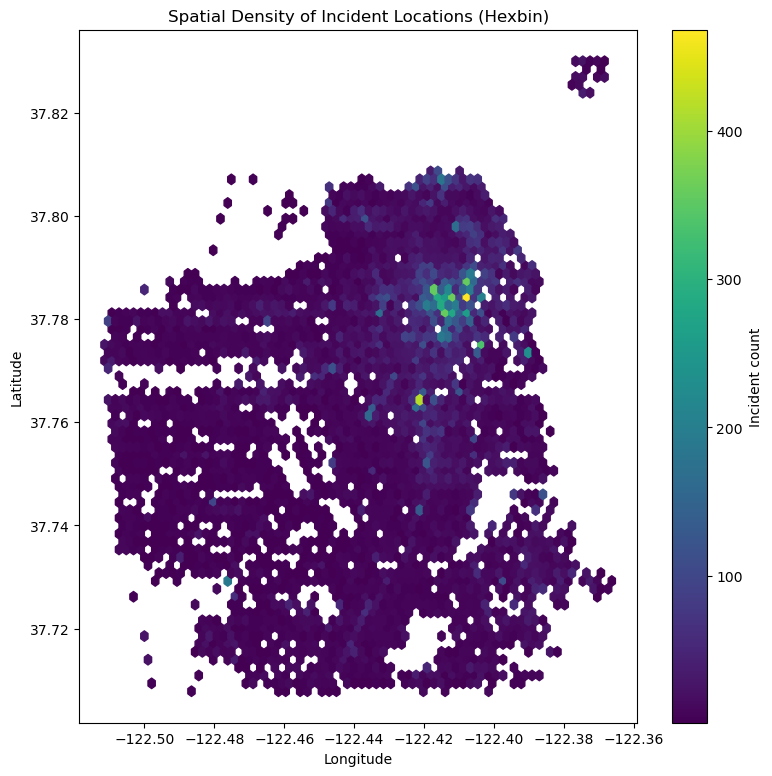

In [16]:
print("\n\n==== Spatial density (hexbin) of incidents ====\n")

df_sample = df.dropna(subset=["latitude", "longitude"]).sample(50000, random_state=42)

plt.figure(figsize=(9, 9))
plt.hexbin(df_sample["longitude"], df_sample["latitude"], gridsize=70, mincnt=1)
plt.title("Spatial Density of Incident Locations (Hexbin)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Incident count")
plt.show()


**Insight:**

The hexbin plot reveals clear spatial clustering of incidents in the northeastern corridor of the city, especially around downtown, the Tenderloin, the Mission, and SoMa. Outer residential neighborhoods show far lower density. This establishes a high-level geographic understanding without the complexity of full GIS mapping.

In [17]:
# =====================================
# Ensure 'month' column exists
# =====================================

df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()

print("Sample of month column:")
display(df[["date", "month"]].head())


Sample of month column:


,date,month
0,2025-08-27,2025-08-01
1,2025-07-17,2025-07-01
2,2025-08-23,2025-08-01
3,2025-08-15,2025-08-01
4,2025-08-15,2025-08-01


**Insight:**

The `month` field enables:

- long-term trend charts
- seasonal pattern detection

- monthly category comparisons

- heatmaps of month × category frequency

This is a standard and essential preprocessing step for time-series EDA.

<a name="neighborhood-naming"></a>
## 2.5 Understanding the Official Neighborhood Naming System


San Francisco uses the official 41-zone Analysis Neighborhood system maintained by DataSF. These zones differ from how residents and tourism guides label neighborhoods; for example, “Financial District/South Beach” appears as a single zone even though it is often treated as two separate areas in everyday language.

All visualizations in this project use these official 41 zones to maintain consistency with SFPD’s reporting structure.

| **Analysis Neighborhood (DataSF)** | **Closest Common Name(s)** |
|-----------------------------------|-----------------------------|
| Bayview Hunters Point | Bayview, Hunters Point, Butchertown |
| Bernal Heights | Bernal Heights |
| Castro/Upper Market | Castro, Upper Market, Duboce Triangle |
| Chinatown | Chinatown |
| Excelsior | Excelsior, Mission Terrace |
| Financial District/South Beach | FiDi, South Beach, Embarcadero |
| Glen Park | Glen Park |
| Golden Gate Park | Golden Gate Park |
| Haight Ashbury | Haight-Ashbury, Cole Valley (partial), Buena Vista |
| Hayes Valley | Hayes Valley, west Civic Center fringe |
| Inner Richmond | Inner Richmond, Central Richmond |
| Inner Sunset | Inner Sunset |
| Japantown | Japantown, NE Western Addition |
| Lakeshore | Lakeshore, Lake Merced, St. Francis Wood fringe |
| Lincoln Park | Lincoln Park, Sea Cliff fringe |
| Lone Mountain/USF | USF area, Lone Mountain |
| Marina | Marina, Cow Hollow |
| McLaren Park | McLaren Park, University Mound fringe |
| Mission | Mission District |
| Mission Bay | Mission Bay, China Basin |
| Nob Hill | Nob Hill, Lower Nob Hill |
| Noe Valley | Noe Valley |
| North Beach | North Beach, Telegraph Hill |
| Oceanview/Merced/Ingleside | OMI: Oceanview, Ingleside, Merced Heights |
| Outer Mission | Outer Mission, Crocker-Amazon |
| Outer Richmond | Outer Richmond |
| Pacific Heights | Pacific Heights, Lower Pacific Heights |
| Portola | Portola, Silver Terrace fringe |
| Potrero Hill | Potrero Hill, Dogpatch fringe |
| Presidio | Presidio |
| Presidio Heights | Presidio Heights, Laurel Heights fringe |
| Russian Hill | Russian Hill |
| Seacliff | Sea Cliff |
| South of Market | SoMa |
| Sunset/Parkside | Outer Sunset, Inner Sunset (west), Parkside |
| Tenderloin | Tenderloin |
| Treasure Island | Treasure Island, Yerba Buena Island |
| Twin Peaks | Twin Peaks, Clarendon Heights |
| Visitacion Valley | Visitacion Valley |
| West Of Twin Peaks | West Portal, Forest Hill, St. Francis Wood |
| Western Addition | Western Addition, Fillmore, Alamo Square, Lower Haight |


#### Insight

Documenting this system prevents confusion during EDA, especially when interpreting neighborhood comparisons. It also establishes the geographic standard that aligns with official SFPD datasets.

### 2.6 Pre-EDA Summary <a id="pre-eda-summary"></a>

Before beginning the exploratory analysis, I completed a focused set of checks to confirm that the dataset is structurally sound and ready for interpretation. The goal was not to create full GIS products, but rather to ensure that time, space, and category variables are correct and internally consistent.

#### ✔ Data Integrity

- The working dataset contains **930,829 crime incidents** from 2018–2025.  
- All core analytical fields are complete, including:  
  `date`, `time`, `incident_datetime`, `hour`, `weekday_name`, `month`, and `year_month`.  
- Missing values appear almost entirely in administrative fields such as **Filed Online** and **CAD Number**, which do not impact crime pattern analysis.

#### ✔ Spatial Readiness (Minimal but Essential)

Only the essential spatial diagnostics were included to avoid unnecessary complexity:

#### 1. Hexbin Spatial Density Plot Completed
- A 50,000-row sample was used to verify spatial clustering.  
- The pattern confirmed expected concentrations in the northeastern corridor (Tenderloin, Mission, SoMa, FiDi).

#### 2. Neighborhood Naming Verified
- The incident dataset uses the official **41 Analysis Neighborhoods** system defined by DataSF.  
- A translation table was documented to help interpret neighborhood names that differ from informal or tourist maps (for example, “Financial District/South Beach”).

#### 3. No Further GIS Processing Required
- Because the dashboard will not include maps, heavier GIS operations  
  (GeoJSON loading, folium boundaries, choropleths, centroid maps)  
  were intentionally omitted to keep the project clean and focused.

This level of spatial preparation is sufficient to interpret neighborhood-level trends without introducing noise.

#### ✔ Temporal Consistency

- A monthly time feature (`month`) was created to support long-range trends and seasonal analysis.  
- Derived fields (`hour`, `weekday_num`, `weekday_name`, `time_of_day`) were validated for consistency.  
- All time fields behave identically across VS Code and Jupyter environments.

#### ✔ Categorical Stability

- Categories are nearly complete (only **0.15%** unclassified).  
- These rows were kept to avoid unnecessary data loss.  
- Category naming is stable and ready for frequency analysis and ranking.

#### ✔ Pre-EDA Diagnostics Completed

The following structural checks were performed and validated:

- Neighborhood distribution  
- Category distribution  
- Weekday distribution  
- Hour-of-day distribution  
- Missing-value profile  
- Spatial density check (hexbin)  
- Monthly field verification  

All indicators confirm that the dataset is in a stable and interpretable state.

#### Conclusion

The dataset is now:

- **Reliable**, with clean and complete key variables  
- **Spatially interpretable**, thanks to minimal but essential checks  
- **Temporally coherent**, with unified date-time fields  
- **Categorically consistent**, with negligible missingness  
- **Appropriately simplified**, avoiding unnecessary GIS noise  
- **Ready for exploratory data analysis**

The notebook now proceeds to:

## 3. Exploratory Data Analysis (EDA) <a id="eda"></a>

The goal of this EDA section is to understand how crime incidents vary over time, across categories, and between neighborhoods in San Francisco from 2018 to 2025. The analysis proceeds from broad temporal patterns to detailed categorical and spatial insights.

### 3.1 Yearly Trends <a id="yearly-trends"></a>

**Goal:** observe long-term changes across 2018-2025
Insights to aim for:

- yearly totals

- pre-COVID vs COVID (2020-2021)

- stabilization after pandemic

- partial-year 2025 dip due to incomplete data

In [18]:
# ===================================
# Yearly Incident Trends (2018-2025) 
# ===================================
# Assuming df is already loaded with 'incident_datetime' and 'year' column

# Ensure year exists
df["year"] = df["incident_datetime"].dt.year
# Group and count incidents by year
yearly_counts = (
    df.groupby("year")
      .size()
      .reset_index(name="incidents")
      .sort_values("year")
)

# Create interactive line plot with Plotly
fig = px.line(
    yearly_counts,
    x="year",
    y="incidents",
    title="Total Incidents per Year (2018–2025)",
    labels={
        "year": "Year",
        "incidents": "Number of Incidents"
    },
    markers=True
)

# Customize the plot
fig.update_layout(
    xaxis=dict(tickmode="array", tickvals=yearly_counts["year"]),
    yaxis=dict(gridcolor="rgba(0,0,0,0.1)"),
    showlegend=False,
    height=500,
    width=900
)
fig.update_traces(line=dict(color="blue"), marker=dict(color="blue", size=8))

# Find peak year and add red arrow annotation
peak_year = yearly_counts.loc[yearly_counts["incidents"].idxmax()]
fig.add_annotation(
    x=peak_year["year"],
    y=peak_year["incidents"],
    text=f"Peak: {peak_year['incidents']:,}",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="red",
    ax=0,
    ay=-30,
    xanchor="left",
    yanchor="top",
    font=dict(size=12),
    bgcolor="white",
    bordercolor="gray",
    borderwidth=1
)

fig.show()

### **Insight: Year-to-Year Crime Trend (2018-2025)**  
The number of recorded incidents peaked in 2018, fell sharply in 2020 during COVID-19 restrictions, and briefly rebounded in 2021-2022. Crime totals then declined steadily, with 2025 appearing lower because the dataset only extends through November. The long-run trend suggests reduced crime levels after 2022, forming a stable basis for future forecasting.

### 3.2 Monthly Trend Visualization <a id="monthly-trend"></a>

Understanding how incident levels change from month to month helps reveal the city’s long-term patterns. A monthly trend smooths out daily fluctuations and shows whether incidents are rising, falling, or stabilizing over time. This view also highlights seasonal cycles - such as quieter winter months and busier summer periods - which become important later when we discuss forecasting in Section 5. The chart below provides a clean, citywide picture of how San Francisco’s incident volume evolved from 2018 through 2025.


In [19]:
# ============================================================
# Interactive Monthly Trend Plot (Plotly) — Custom Month Ticks
# ============================================================
import plotly.io as pio
pio.renderers.default = "notebook"  # for classic Jupyter Notebook

# Build monthly counts
monthly_counts = (
    df.groupby("month")
      .size()
      .reset_index(name="incidents")
      .sort_values("month")
)

# Make sure "month" is real datetime
monthly_counts["month"] = pd.to_datetime(monthly_counts["month"])

# Select every 6th month for x-axis tick labels
tick_positions = monthly_counts["month"][::6]
tick_labels = tick_positions.dt.strftime("%Y-%m")

fig = px.line(
    monthly_counts,
    x="month",
    y="incidents",
    markers=True,
    title="Monthly Incident Trend (2018-2025)",
    labels={"month": "Month", "incidents": "Number of Incidents"},
    hover_data={"month": "|%Y-%m", "incidents": ":,"}
)

fig.update_layout(
    template="plotly_white",
    title_font_size=16,
    xaxis_title="Month",
    yaxis_title="Incidents",
    hoverlabel_font_size=14,
    xaxis=dict(
        tickmode="array",
        tickvals=tick_positions,
        ticktext=tick_labels,
        tickangle=45
    )
)

fig.write_image(
    "dashboard_charts_final/monthly_trend.png",
    width=1000,
    height=600,
    scale=2
)

fig.show()

**Insight: Monthly Trend (2018-2025)**

The monthly timeline shows clear seasonality and several structural shifts in crime levels across the eight-year period. Incidents typically reach their highest levels during the summer and early fall months. A pronounced drop appears in early 2020, coinciding with the onset of COVID-19 restrictions, which sharply reduced movement and activity across the city. Crime counts rise again during 2021 and 2022 as activity resumes, but they do not reach the higher levels seen before 2020.

From late 2022 onward, the monthly totals follow a consistent downward path, with 2024 showing the lowest sustained levels in the post-pandemic period. The sharp decline in late 2025 reflects the fact that the dataset ends in November, not a true collapse in activity. Overall, the pattern suggests that the city’s incident volume has stabilized at a level noticeably below the pre-2020 range, indicating a long-term shift rather than a temporary fluctuation.

### 3.3 Weekday Patterns <a id="weekday-patterns"></a>

Understanding how incidents vary by weekday helps reveal workweek vs weekend dynamics, commuting effects, and daily patterns of activity. This section examines the distribution of incidents from Monday through Sunday.


In [20]:
# ============================================================
# STEP 1 — Create weekday summary table
# ============================================================

# Ensure datetime column exists
# Your dataset uses 'incident_datetime', not 'Incident Date'
df["day_of_week"] = df["incident_datetime"].dt.dayofweek   # 0 = Mon ... 6 = Sun

# Add readable weekday labels
weekday_map = {
    0: "Mon", 1: "Tue", 2: "Wed",
    3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"
}
df["day_label"] = df["day_of_week"].map(weekday_map)

# Count incidents per weekday (ensure correct weekday order)
weekday_counts = (
    df["day_label"]
        .value_counts()
        .reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
        .reset_index()
)

weekday_counts.columns = ["day_label", "incidents"]

weekday_counts


,day_label,incidents
0,Mon,131168
1,Tue,132094
2,Wed,139663
3,Thu,134042
4,Fri,142401
5,Sat,129824
6,Sun,121637


In [21]:
df.columns


Index(['Row ID', 'Incident Datetime', 'date', 'time', 'incident_year',
       'weekday', 'Report Datetime', 'Incident ID', 'Incident Number',
       'CAD Number', 'Report Type Code', 'Report Type Description',
       'Filed Online', 'Incident Code', 'category', 'Incident Subcategory',
       'Incident Description', 'Resolution', 'Intersection', 'CNN',
       'Police District', 'neighborhood', 'Supervisor District',
       'Supervisor District 2012', 'latitude', 'longitude', 'Point',
       'data_as_of', 'data_loaded_at', 'year', 'incident_datetime', 'hour',
       'month', 'weekday_num', 'weekday_name', 'year_month', 'time_of_day',
       'geometry', 'day_of_week', 'day_label'],
      dtype='object')

In [22]:
# ============================================================
# STEP 1 — Create weekday summary table
# ============================================================

# Use the correct datetime column: 'incident_datetime'
df["day_of_week"] = df["incident_datetime"].dt.dayofweek   # 0 = Mon ... 6 = Sun

# Add readable weekday labels
weekday_map = {
    0: "Mon", 1: "Tue", 2: "Wed",
    3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"
}
df["day_label"] = df["day_of_week"].map(weekday_map)

# Count incidents for each weekday (ensure correct order)
weekday_counts = (
    df["day_label"]
      .value_counts()
      .reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
      .reset_index()
)

weekday_counts.columns = ["day_label", "incidents"]

weekday_counts


,day_label,incidents
0,Mon,131168
1,Tue,132094
2,Wed,139663
3,Thu,134042
4,Fri,142401
5,Sat,129824
6,Sun,121637


In [23]:
# --- Bar chart with custom color palette (one color per weekday) ---
fig = px.bar(
    weekday_counts,
    x="day_label",
    y="incidents",
    title="Incident Distribution by Weekday",
    labels={
        "day_label": "Day of Week",
        "incidents": "Number of Incidents"
    },
    color="day_label",  # color by weekday (categorical)
    color_discrete_sequence=[
        "#1f4e79",  # Mon – deep blue
        "#23689b",  # Tue – blue
        "#2780b9",  # Wed – blue-teal
        "#2a9cc2",  # Thu – lighter teal
        "#31b0d5",  # Fri – light blue
        "#4fc3f7",  # Sat – soft cyan
        "#81d4fa"   # Sun – pale blue
    ],
    hover_data={"incidents": ":", "day_label": False}
)

# --- Layout style: clean white background, subtle grid ---
fig.update_layout(
    xaxis=dict(
        tickangle=0,
        showline=True,
        linewidth=1,
        linecolor="rgba(0,0,0,0.25)"
    ),
    yaxis=dict(
        gridcolor="rgba(0,0,0,0.08)",
        zeroline=False,
        showline=True,
        linewidth=1,
        linecolor="rgba(0,0,0,0.25)"
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,
    title_font=dict(size=20),
    xaxis_title_font=dict(size=14),
    yaxis_title_font=dict(size=14),
    height=500,
    width=900,
    margin=dict(l=60, r=40, t=60, b=60)
)

# --- Add value labels on bars ---
for _, row in weekday_counts.iterrows():
    fig.add_annotation(
        x=row["day_label"],
        y=row["incidents"],
        text=f"{row['incidents']:,}",
        showarrow=False,
        font=dict(size=11),
        yshift=10
    )

fig.write_image(
    "dashboard_charts_final/weekday_pattern.png",
    width=900,
    height=600,
    scale=2
)
fig.show()


**Interpretation**

The weekday distribution reveals a clear work-week pattern:

- **Friday** records the highest number of incidents (≈142k), likely influenced by increased evening activity and end-of-week movement.
- **Wednesday** and **Thursday** remain consistently high, showing mid-week peak behaviors.
- **Saturday** and **Sunday** show lower totals, especially Sunday (≈121k), reflecting reduced work-related mobility.
- Overall, crime is generally higher during the **workweek (Mon-Fri)**, aligning with increased commuting, business activity, and foot traffic.

These patterns help inform staffing and patrol strategies, especially around mid-week and late-week peaks.

### 3.4 Hour-of-Day Patterns <a id="hour-patterns"></a>

This section examines how incidents vary during a 24-hour period. Hourly patterns often reveal late-night crime activity, afternoon peaks, and daily behavioral cycles associated with commuting, nightlife, and police response timing.

In [24]:
# ============================================================
# 3.4 Hour-of-Day Patterns - 24-Hour Crime Cycle
# ============================================================


# ------------------------------------------------------------
# STEP 1: Extract the hour (0-23) from the incident timestamp
# ------------------------------------------------------------
df["hour"] = df["incident_datetime"].dt.hour

# ------------------------------------------------------------
# STEP 2: Count how many incidents occur in each hour
# ------------------------------------------------------------
hourly_counts = (
    df.groupby("hour")
      .size()
      .reset_index(name="incidents")
      .sort_values("hour")
)

# ------------------------------------------------------------
# STEP 3: Build the bar chart
# ------------------------------------------------------------
# Custom professional gradient from navy → blue → teal
custom_colors = [
    "#0A4D68",  # deep navy blue
    "#1679AB",  # strong blue
    "#3BACB6",  # blue-green
    "#82DBD8"   # soft teal
]

fig = px.bar(
    hourly_counts,
    x="hour",
    y="incidents",
    title="Incident Distribution by Hour of Day",
    labels={
        "hour": "Hour of Day (0-23)",
        "incidents": "Number of Incidents"
    },

    # Apply the custom gradient based on incident count
    color="incidents",
    color_continuous_scale=custom_colors,

    hover_data={"incidents": ":", "hour": False}
)

# ------------------------------------------------------------
# STEP 4: Style the chart to look clean and professional
# ------------------------------------------------------------
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,

    xaxis=dict(
        tickmode="array",
        tickvals=list(range(24)),      # show 0-23
        showline=True,
        linecolor="rgba(0,0,0,0.25)",
        gridcolor="rgba(0,0,0,0.08)"
    ),
    yaxis=dict(
        showline=True,
        linecolor="rgba(0,0,0,0.25)",
        gridcolor="rgba(0,0,0,0.08)"
    ),

    height=500,
    width=1000
)

# ------------------------------------------------------------
# STEP 5: Add text labels above each bar
# ------------------------------------------------------------
for _, row in hourly_counts.iterrows():
    fig.add_annotation(
        x=row["hour"],
        y=row["incidents"],
        text=f"{row['incidents']:,}",
        showarrow=False,
        yshift=10,
        font=dict(size=10)
    )

# ------------------------------------------------------------
# STEP 6: Save the figure and display it
# ------------------------------------------------------------
fig.write_image(
    "dashboard_charts_final/hourly_pattern.png",
    width=900,
    height=600,
    scale=2
)

fig.show()


**Interpretation**

The 24-hour cycle shows a strong and realistic pattern:

- **Midnight (0:00)** shows one of the highest peaks, reflecting nightlife, alcohol-related incidents, and late-night activity.
- Crime activity drops to its lowest between **2 AM and 5 AM**, when the city is least active.
- Beginning at **7-9 AM**, incidents rise as the city wakes, commutes begin, and public activity increases.
- The **highest peak occurs at 12 PM**, followed by consistently elevated activity through the afternoon and early evening.
- Evening hours (**4-8 PM**) remain active due to traffic, work transitions, and crowded public spaces, before gradually tapering off.

These hourly dynamics align with typical urban crime patterns and help guide patrol scheduling and resource allocation.

### 3.5 Crime Category Distribution <a id="category-distribution"></a>

This section examines the distribution of crime categories across the dataset. Understanding which types dominate helps reveal citywide patterns such as property-crime prevalence, seasonal trends, and public-safety priorities.


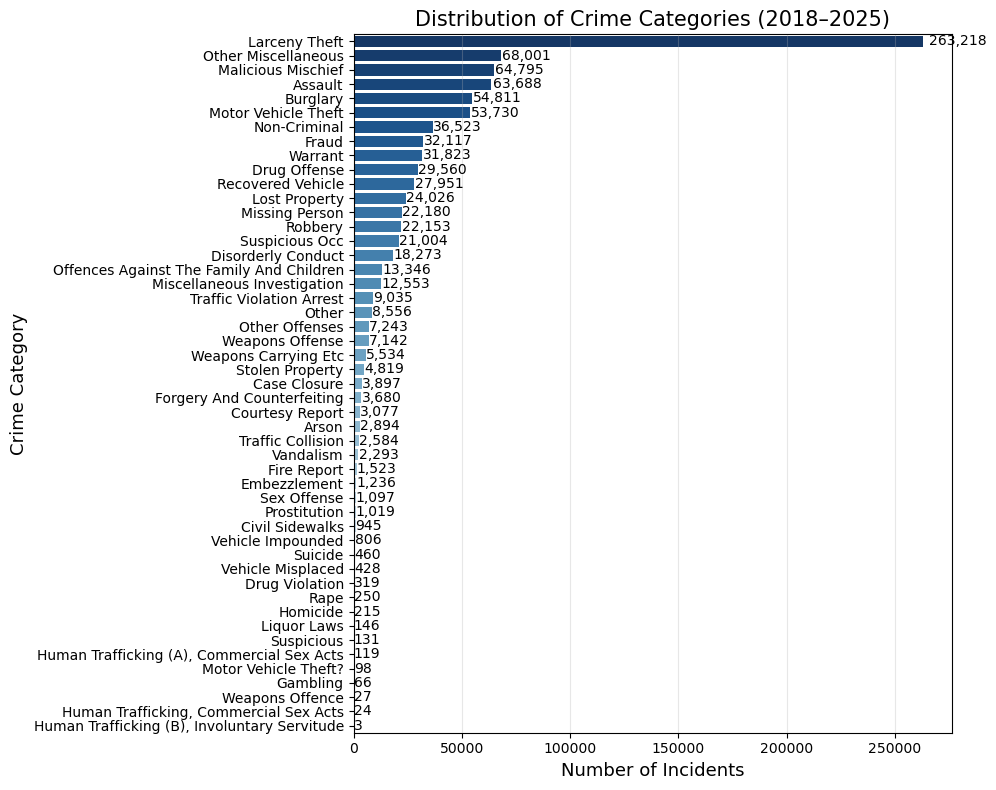

,category,incidents
0,Larceny Theft,263218
1,Other Miscellaneous,68001
2,Malicious Mischief,64795
3,Assault,63688
4,Burglary,54811
5,Motor Vehicle Theft,53730
6,Non-Criminal,36523
7,Fraud,32117
8,Warrant,31823
9,Drug Offense,29560


In [25]:
# ============================================================
# 3.5 Crime Category Distribution — Horizontal Ranking Chart
# ============================================================

category_col = "category"   # from df.columns

# Count incidents by category
category_counts = df[category_col].value_counts().reset_index()
category_counts.columns = ["category", "incidents"]

plt.figure(figsize=(10, 8))

sns.barplot(
    data=category_counts,
    y="category",
    x="incidents",
    hue="category",
    dodge=False,
    palette="Blues_r"
)

plt.legend([], [], frameon=False)  # hide legend

plt.title("Distribution of Crime Categories (2018–2025)", fontsize=15)
plt.xlabel("Number of Incidents", fontsize=13)
plt.ylabel("Crime Category", fontsize=13)

# Add labels to bars
for index, row in category_counts.iterrows():
    plt.text(
        row["incidents"] + row["incidents"] * 0.01,
        index,
        f"{row['incidents']:,}",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

category_counts


In [26]:
#pip install "plotly[kaleido]"


In [27]:
# ============================================================
# 3.5 Crime Category Distribution - Top 10 Categories
# ============================================================

# ------------------------------------------------------------
# STEP 1: Select the category column and count category totals
# ------------------------------------------------------------
category_col = "category"

category_counts = (
    df[category_col]
    .value_counts()
    .reset_index()
)

category_counts.columns = ["category", "incidents"]

# ------------------------------------------------------------
# STEP 2: Keep the Top 10 categories and sort from smallest to largest
# ------------------------------------------------------------
top10 = category_counts.head(10).sort_values("incidents")

# ------------------------------------------------------------
# STEP 3: Create the horizontal bar chart
# ------------------------------------------------------------
# Same professional gradient as your other charts:
custom_colors = [
    "#0A4D68",  # deep navy blue
    "#1679AB",  # strong blue
    "#3BACB6",  # blue-green
    "#82DBD8"   # soft teal
]

fig = px.bar(
    top10,
    x="incidents",
    y="category",
    title="Top 10 Crime Categories (2018-2025)",
    labels={
        "incidents": "Number of Incidents",
        "category": "Crime Category"
    },
    orientation="h",

    # Apply the same gradient color scale for consistency
    color="incidents",
    color_continuous_scale=custom_colors,

    hover_data={"incidents": ":", "category": False}
)

# ------------------------------------------------------------
# STEP 4: Style the chart to match the rest of the dashboard
# ------------------------------------------------------------
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,

    xaxis=dict(
        gridcolor="rgba(0,0,0,0.10)",
        showline=True,
        linecolor="rgba(0,0,0,0.25)"
    ),
    yaxis=dict(
        gridcolor="rgba(0,0,0,0.10)",
        showline=True,
        linecolor="rgba(0,0,0,0.25)"
    ),

    height=600,
    width=1000
)

# ------------------------------------------------------------
# STEP 5: Add value labels inside each bar (white text for clarity)
# ------------------------------------------------------------
fig.update_traces(
    texttemplate="%{x:,}",       # display number with commas
    textposition="inside",
    textfont=dict(color="white", size=10),
    insidetextanchor="end"
)

# ------------------------------------------------------------
# STEP 6: Save the figure and display it
# ------------------------------------------------------------
fig.write_image(
    "dashboard_charts_final/top_categories.png",
    width=1000,
    height=700,
    scale=2
)

fig.show()


### Insight: Crime Category Distribution (2018-2025)

San Francisco’s crime landscape is shaped primarily by **property-related offenses**, not violent incidents. Theft, burglary, and motor vehicle theft form the core of the city’s crime burden, while violent events such as assault occur at much lower levels. This means the city’s operational and prevention challenges center on stolen property, repeat hotspots, and opportunistic incidents rather than interpersonal violence.

#### Key Points 
1. **Larceny Theft accounts for nearly 40% of all reported incidents (2018-2025)**, making it the single most influential category in shaping overall crime trends.
2. The sharp drop from the #1 category to the next illustrates a **long-tail distribution**, where one dominant crime type outweighs all others.
3. **Forecasting, seasonality analysis, and hotspot modeling must analyze Larceny Theft separately**, because its scale can overshadow patterns in other categories.



### 3.6 Neighborhood Distribution <a id="neighborhood-distribution"></a>

After examining temporal patterns and crime categories, the next step is to understand **where** incidents are concentrated across the city. Neighborhood-level distribution provides a geographic perspective on crime, revealing local hotspots, variations in incident volume, and areas that contribute most to the overall crime burden. This forms the foundation for spatial mapping, hotspot detection, and resource allocation strategies in later sections.


In [28]:
# ============================================================
# 3.6 Neighborhood Distribution — Top 15 Neighborhoods
# ============================================================


# ------------------------------------------------------------
# STEP 1: Count incidents by neighborhood
# ------------------------------------------------------------
nbh_counts = (
    df["neighborhood"]
    .value_counts()
    .reset_index()
)

# Rename columns for clarity
nbh_counts.columns = ["neighborhood", "incidents"]

# ------------------------------------------------------------
# STEP 2: Select Top 15 and sort ascending
# ------------------------------------------------------------
nbh_top15 = nbh_counts.head(15).sort_values("incidents")

# ------------------------------------------------------------
# STEP 3: Create the horizontal bar chart
# ------------------------------------------------------------
# Same professional gradient for consistency across dashboard:
custom_colors = [
    "#0A4D68",  # deep navy blue
    "#1679AB",  # strong blue
    "#3BACB6",  # blue-green
    "#82DBD8"   # soft teal
]

fig = px.bar(
    nbh_top15,
    x="incidents",
    y="neighborhood",
    title="Top 15 Neighborhoods by Incident Count (2018-2025)",
    labels={
        "incidents": "Number of Incidents",
        "neighborhood": "Neighborhood"
    },
    orientation="h",

    # Apply consistent gradient
    color="incidents",
    color_continuous_scale=custom_colors,

    hover_data={"incidents": ":", "neighborhood": False}
)

# ------------------------------------------------------------
# STEP 4: Style the chart to match entire dashboard theme
# ------------------------------------------------------------
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,

    xaxis=dict(
        gridcolor="rgba(0,0,0,0.10)",
        showline=True,
        linecolor="rgba(0,0,0,0.25)"
    ),
    yaxis=dict(
        gridcolor="rgba(0,0,0,0.10)",
        showline=True,
        linecolor="rgba(0,0,0,0.25)"
    ),

    height=700,
    width=1000
)

# ------------------------------------------------------------
# STEP 5: Add white value labels inside each bar
# ------------------------------------------------------------
fig.update_traces(
    texttemplate="%{x:,}",      # commas in numbers
    textposition="inside",
    textfont=dict(color="white", size=9),
    insidetextanchor="end"
)

# ------------------------------------------------------------
# STEP 6: Save the figure and show it
# ------------------------------------------------------------
fig.write_image(
    "dashboard_charts_final/top_neighborhoods.png",
    width=1000,
    height=700,
    scale=2
)

fig.show()


#### Key Insights from Neighborhood Distribution

The top neighborhoods show a clear pattern: crime in San Francisco is geographically concentrated rather than evenly distributed across the city.

1. Mission and Tenderloin dominate incident volume  
These two neighborhoods alone account for more than 200,000 incidents, making them the city’s primary high-activity zones. Both areas combine dense foot traffic, commercial corridors, nightlife, and transit access, producing consistent incident volume year-round.

2. South of Market (SoMa) and Financial District/South Beach form the second tier 
These areas reflect a mix of office districts, nightlife, tourism, and large residential growth. Their high ranking indicates that downtown and near-downtown areas remain the most active regions for reported incidents.

3. Bayview Hunters Point stands out geographically  
Unlike the neighborhoods above, Bayview is not a central district. Its high count suggests **localized hotspots**, driven by concentrated residential density and long-standing socioeconomic disparities.

4. Most other neighborhoods show a gradual decline in incidents  
Western Addition, North Beach, Sunset, Nob Hill, Marina, and Castro/Upper Market fall into a mid-level range of 25,000-33,000 incidents, indicating moderate but steady activity.

5. The distribution follows a classic long-tail pattern 
A few neighborhoods account for a disproportionate share of crime. This means:  
- Citywide strategy must focus on small, consistently high-activity zones.  
- Hotspot-based forecasting and patrol optimization are more effective than uniform coverage.  
- Neighborhood-level variation is essential for mapping, resource allocation, and later forecasting.

  
> Crime in San Francisco is not evenly spread. It clusters heavily in specific neighborhoods, and understanding this spatial concentration is crucial for analysis, policy recommendations, and any predictive model built later in your project.


### 3.7 Time-of-Day vs Crime Category (Heatmap) <a id="tod-category-heatmap"></a>

Understanding how different crime categories behave across the 24-hour cycle helps reveal temporal patterns that are invisible in daily or monthly aggregates.
Some categories peak sharply at night, others rise during business hours, and some remain steady throughout the day.
A heatmap makes these contrasts clear at a glance.

In [29]:
# ============================================================
# 3.7 Time-of-Day vs Crime Category - Heatmap (Interactive Version)
# ============================================================

# ------------------------------------------------------------
# STEP 1: Ensure the hour column exists
# ------------------------------------------------------------
df["hour"] = df["incident_datetime"].dt.hour

# ------------------------------------------------------------
# STEP 2: Create pivot table (rows = category, columns = hour)
# ------------------------------------------------------------
heatmap_data = df.pivot_table(
    index="category",
    columns="hour",
    values="Incident Number",   # any unique column works
    aggfunc="count",
    fill_value=0
)

# ------------------------------------------------------------
# STEP 3: Keep the Top 15 categories for readability
# ------------------------------------------------------------
top15_cats = (
    df["category"]
    .value_counts()
    .head(15)
    .index
)

heatmap_subset = heatmap_data.loc[top15_cats]

# ------------------------------------------------------------
# STEP 4: Dashboard-consistent color scale (navy → blue → teal)
# ------------------------------------------------------------
consistent_scale = [
    "#0A4D68",   # deep navy
    "#1679AB",   # strong blue
    "#3BACB6",   # blue-green
    "#82DBD8"    # soft teal
]

# ------------------------------------------------------------
# STEP 5: Create the heatmap with visible values
# ------------------------------------------------------------
fig = px.imshow(
    heatmap_subset,
    color_continuous_scale=consistent_scale,
    title="Top 15 Crime Categories - Hour-of-Day Pattern (2018-2025)",
    labels=dict(
        x="Hour of Day (0-23)",
        y="Crime Category",
        color="Number of Incidents"
    ),
    aspect="auto",
    text_auto=True     # display numbers inside each cell
)

# ------------------------------------------------------------
# STEP 6: Style the heatmap to match the dashboard theme
# ------------------------------------------------------------
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",

    xaxis=dict(
        showgrid=True,
        gridcolor="rgba(0,0,0,0.1)",
        gridwidth=0.7,
        tickmode="array",
        tickvals=list(range(24))
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="rgba(0,0,0,0.1)",
        gridwidth=0.7
    ),

    coloraxis_colorbar=dict(title="Number of Incidents"),

    height=850,
    width=1400
)

# ------------------------------------------------------------
# STEP 7: Add thin dashed cell boundaries for readability
# ------------------------------------------------------------
for i in range(1, len(heatmap_subset.index)):
    fig.add_hline(
        y=i,
        line_dash="dash",
        line_color="gray",
        line_width=0.4
    )

for i in range(1, len(heatmap_subset.columns)):
    fig.add_vline(
        x=i,
        line_dash="dash",
        line_color="gray",
        line_width=0.4
    )

# ------------------------------------------------------------
# STEP 8: Save the figure and display it
# ------------------------------------------------------------
fig.write_image(
    "dashboard_charts_final/hour_weekday_heatmap.png",
    width=900,
    height=600,
    scale=2
)

fig.show()


#### Key Insight: Hour-of-Day Patterns by Crime Category

The heatmap shows a clear separation between property-driven crimes and other categories when viewed hourly.

1. Larceny Theft dominates every hour of the day.  
Its activity rises sharply from 8 AM, peaks between **11 AM and 4 PM**, and declines after 7 PM.  
This midday peak aligns with:
- business activity  
- tourist foot traffic  
- retail store operating hours  

2. Other property crimes follow similar daytime profiles.  
Categories like *Burglary, Motor Vehicle Theft,* and *Malicious Mischief* increase during normal work hours, indicating offenses often occur when residents are away or distracted.

3. Violent crime (e.g., Assault) shows a different pattern.  
Assault rises later in the day, with visible growth after **2 PM**, remaining steady into the evening.  
This reflects social activity patterns: nightlife, gatherings, and interpersonal conflict occur later than property theft.

4. Early-morning hours (1 AM–5 AM) show low activity for nearly all categories. 
The drop reflects reduced mobility, fewer open businesses, and less environmental opportunity.

#### Takeaway

Hourly patterns underline a major theme in San Francisco’s crime data:
property crime is highest during daytime economic activity, while interpersonal or opportunistic crimes shift toward the evening.  
This distinction is critical for:
- resource and patrol scheduling  
- risk-aware forecasting models  
- targeted prevention strategies in business and residential corridors.



Before examining neighborhood hotspots and long-term forecasting, it is important to understand *when* different crime categories are most active.  
A single combined heatmap hides major differences between property-related crimes and interpersonal or enforcement-related crimes.  

To highlight these contrasting temporal patterns, I created **two side-by-side heatmaps** using the same 0-23 hour axis:

- one for **Property Crime Categories** (e.g., Larceny Theft, Burglary, Motor Vehicle Theft)
- one for **Assault / Robbery / Other Categories**

This split makes the hourly “behavior” of each crime group easier to compare and reveals patterns that influence patrol planning, resource allocation, and forecasting.


In [30]:
# ============================================================
# 3.7 Dual Heatmaps - Property vs Assault/Robbery/Other
# ============================================================

# ------------------------------------------------------------
# STEP 1: Build category groups using keywords
# ------------------------------------------------------------
all_cats = list(heatmap_data.index)

# Property-related keywords
property_keywords = [
    "larceny", "theft", "burglary", "vehicle", "auto",
    "vandalism", "malicious mischief", "property"
]

# Interpersonal / enforcement crime keywords
other_keywords = [
    "assault", "robbery", "drug", "narcotic",
    "warrant", "non-criminal", "suspicious", "missing person"
]

property_cats = []
other_cats = []

# Assign categories based on name matching
for c in all_cats:
    name = c.lower()
    if any(k in name for k in property_keywords):
        property_cats.append(c)
    elif any(k in name for k in other_keywords):
        other_cats.append(c)

print("Property categories found:", property_cats)
print("Assault/Robbery/Other categories found:", other_cats)

# Fallback if keywords fail
if len(property_cats) == 0 or len(other_cats) == 0:
    print("Not enough matches - using top 10 categories instead.")
    top_cats = df["category"].value_counts().head(10).index
    property_cats = list(top_cats[:5])
    other_cats = list(top_cats[5:10])

property_data = heatmap_data.loc[property_cats]
other_data    = heatmap_data.loc[other_cats]

# ------------------------------------------------------------
# STEP 2: Dashboard color scale (navy → blue → teal)
# ------------------------------------------------------------
consistent_scale = [
    "#0A4D68",   # deep navy
    "#1679AB",   # strong blue
    "#3BACB6",   # blue-green
    "#82DBD8"    # soft teal
]

# ------------------------------------------------------------
# STEP 3: Property crime heatmap
# ------------------------------------------------------------
fig_property = px.imshow(
    property_data,
    color_continuous_scale=consistent_scale,
    title="Property Crime Categories - Hour-of-Day Pattern (2018-2025)",
    labels=dict(
        x="Hour of Day (0-23)",
        y="Crime Category",
        color="Number of Incidents"
    ),
    aspect="auto",
    text_auto=True
)

fig_property.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    height=400,
    width=900
)

fig_property.update_xaxes(
    tickmode="array",
    tickvals=list(range(0, 24, 2))
)

fig_property.show()

# ------------------------------------------------------------
# STEP 4: Assault / Robbery / Other crime heatmap
# ------------------------------------------------------------
fig_other = px.imshow(
    other_data,
    color_continuous_scale=consistent_scale,
    title="Assault / Robbery / Other Categories - Hour-of-Day Pattern (2018-2025)",
    labels=dict(
        x="Hour of Day (0-23)",
        y="Crime Category",
        color="Number of Incidents"
    ),
    aspect="auto",
    text_auto=True
)

fig_other.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    height=400,
    width=900
)

fig_other.update_xaxes(
    tickmode="array",
    tickvals=list(range(0, 24, 2))
)

fig_other.show()


Property categories found: ['Burglary', 'Larceny Theft', 'Lost Property', 'Malicious Mischief', 'Motor Vehicle Theft', 'Motor Vehicle Theft?', 'Recovered Vehicle', 'Stolen Property', 'Vandalism', 'Vehicle Impounded', 'Vehicle Misplaced']
Assault/Robbery/Other categories found: ['Assault', 'Drug Offense', 'Drug Violation', 'Missing Person', 'Non-Criminal', 'Robbery', 'Suspicious', 'Suspicious Occ', 'Warrant']


#### Insights from the Dual Hour-of-Day Heatmaps

The two heatmaps show clear and meaningful differences in the hourly behavior of property crimes versus interpersonal or enforcement-related crimes.

#### 1. Property Crimes Peak Earlier in the Day
Property-related categories (such as *Larceny Theft, Burglary, Lost Property,* and *Vehicle-Related offenses*) rise through the late morning and reach their highest activity between **1 PM and 6 PM**.  
These patterns align with business hours, retail activity, and periods of heavier pedestrian and vehicle movement.

#### 2. Assault, Robbery, and Enforcement Crimes Peak Later
Interpersonal and enforcement categories follow a later schedule:

- **Assault** increases through the afternoon and peaks between **6 PM and 10 PM**.  
- **Robbery** also becomes more frequent during evening and nighttime hours.  
- **Drug-related incidents, warrants, and suspicious activity** rise in the late afternoon and remain active into the evening.

#### 3. Distinct Rhythms Between Crime Groups
- **Property crimes** cluster during daytime and early evening.  
- **Assault/robbery/enforcement crimes** shift toward **evening and nighttime** activity.

These contrasting patterns highlight why a single combined heatmap can be misleading and why separating crime groups is more informative.

#### 4. Operational Value
Understanding these differences supports:

- More effective **patrol scheduling**  
- Better **resource allocation across shifts**  
- Improved **forecasting accuracy**, since each crime group follows a different daily cycle


### 3.8 Neighborhood × Category Matrix <a id="neighborhood-category-matrix"></a>

Understanding which crime types dominate each neighborhood provides a deeper view into local safety conditions.  
Some neighborhoods may be driven primarily by property crime, while others may show higher concentrations of assaults, drug offenses, or calls classified as suspicious occurrences.

A **Neighborhood × Category matrix** highlights these differences by showing how the top crime categories distribute across the highest-incident neighborhoods.  
This matrix forms the foundation for identifying neighborhood “profiles,” guiding targeted interventions, and supporting later spatial analysis and hotspot mapping.


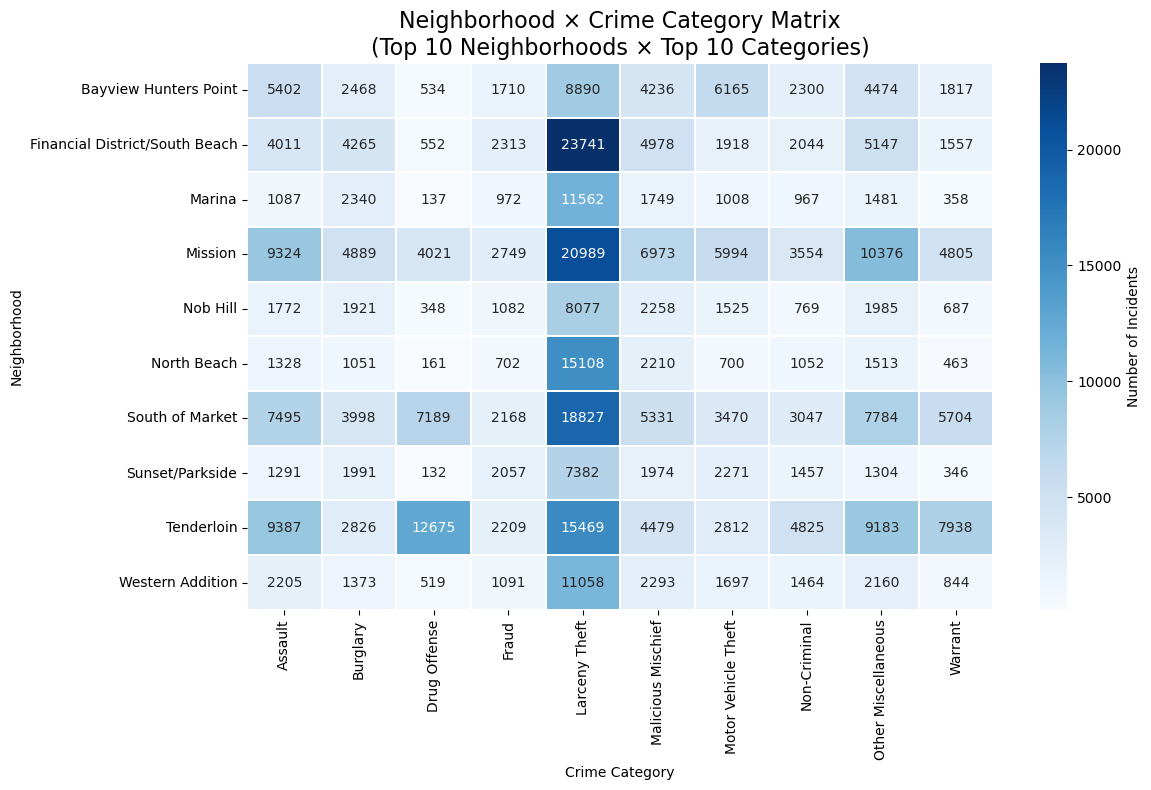

In [31]:
# ============================================================
# 3.8 Neighborhood × Category Matrix (Top 10 × Top 10)
# ============================================================

# ---- Step 1: Top 10 neighborhoods ----
top_neighborhoods = (
    df['neighborhood']
      .value_counts()
      .head(10)
      .index
)

# ---- Step 2: Top 10 crime categories ----
top_categories = (
    df['category']
      .value_counts()
      .head(10)
      .index
)

# ---- Step 3: Filter dataset ----
df_matrix = df[
    df['neighborhood'].isin(top_neighborhoods) &
    df['category'].isin(top_categories)
]

# ---- Step 4: Build pivot table ----
matrix = pd.pivot_table(
    df_matrix,
    values='Incident Number',   # any column works because we count size()
    index='neighborhood',
    columns='category',
    aggfunc='size',
    fill_value=0
)

# ---- Step 5: Heatmap ----
plt.figure(figsize=(12, 8))

sns.heatmap(
    matrix,
    cmap="Blues",
    annot=True,
    fmt="d",
    linewidths=0.3,
    cbar_kws={"label": "Number of Incidents"}
)

plt.title("Neighborhood × Crime Category Matrix\n(Top 10 Neighborhoods × Top 10 Categories)", fontsize=16)
plt.xlabel("Crime Category")
plt.ylabel("Neighborhood")

plt.tight_layout()
plt.show()

#### Insight: 

- Crime patterns differ sharply by neighborhood rather than being uniform across the city.  
- Larceny Theft dominates almost every high-incident neighborhood, especially Financial District/South Beach, Mission, SoMa, and Tenderloin.  
- Tenderloin shows the widest crime mix, with high Drug Offense, Warrant, Non-Criminal, and Theft incidents.  
- Financial District/South Beach is overwhelmingly theft-driven with minimal activity in other categories.  
- Mission and SoMa show blended patterns, combining high theft with assault, fraud, and malicious mischief.  
- Bayview Hunters Point leans more toward violence-adjacent categories (Assault, Motor Vehicle Theft) compared with many other areas.  
- Drug Offense clusters heavily in Tenderloin, SoMa, and Mission, not citywide.

**Implication:**  
Neighborhoods behave differently and should be modeled as distinct crime environments for forecasting and resource planning.


### 3.9 Year-Month Trend by Category <a id="year-month-category"></a>

To understand how individual crime categories evolve over time, we break down monthly trends for the Top 6 crime categories. This helps reveal whether certain crime types rise, decline, or show seasonal patterns independent of overall citywide crime levels.

In [32]:
# ============================================================
# 3.9 Year–Month Trend by Category (Top 6 Categories) (Interactive Version)
# ============================================================
# Assuming df is already loaded with 'incident_datetime' and 'category' columns

# Ensure month-year datetime for grouping
df["year_month"] = df["incident_datetime"].dt.to_period("M").dt.to_timestamp()

# Get top 6 categories
top6 = df["category"].value_counts().head(6).index.tolist()

# Create pivot table: rows = year_month, columns = category (top6 only)
pivot_cat = (
    df[df["category"].isin(top6)]
    .groupby(["year_month", "category"])
    .size()
    .unstack(fill_value=0)
    .loc[:, top6]  # Ensure columns are top6
)

# Melt to long form for easier plotting with px
melted_df = pivot_cat.reset_index().melt(
    id_vars="year_month",
    var_name="category",
    value_name="incidents"
)

# Create interactive line plot with Plotly
fig = px.line(
    melted_df,
    x="year_month",
    y="incidents",
    color="category",
    title="Monthly Crime Trends by Category (Top 6, 2018-2025)",
    labels={
        "year_month": "Year-Month",
        "incidents": "Number of Incidents",
        "category": "Category"
    },
    markers=True
)

# Customize the plot
fig.update_layout(
    xaxis=dict(
        tickformat="%Y-%m",
        dtick="M6",  # Every 6 months
        tickangle=45
    ),
    yaxis=dict(gridcolor="rgba(0,0,0,0.1)"),
    showlegend=True,
    legend=dict(
        title="Category",
        x=1.02,
        y=1
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=500,
    width=1400
)
fig.update_traces(line=dict(width=2))

fig.show()

# Optional: Display the pivot table
pivot_cat

category,Larceny Theft,Other Miscellaneous,Malicious Mischief,Assault,Burglary,Motor Vehicle Theft
year_month,,,,,,
2018-01-01,4091,1048,759,709,606,415
2018-02-01,3183,935,655,683,539,358
2018-03-01,3550,952,734,753,582,396
2018-04-01,3400,1002,730,795,590,382
2018-05-01,3541,966,692,805,640,449
...,...,...,...,...,...,...
2025-07-01,1523,553,507,618,337,335
2025-08-01,1595,532,476,592,407,339
2025-09-01,1492,452,476,636,385,324


#### Insight: Year-Month Trends by Category

- **Larceny Theft shows a long-term decline**, with high peaks in 2018-2019, a sharp drop in early 2020, partial recovery in 2021-2022, and another decline into 2024-2025.
- Other Miscellaneous, Malicious Mischief, and Assault remain stable, showing small, regular seasonal fluctuations.
- Motor Vehicle Theft and Burglary stay relatively consistent, with burglary showing a brief rise during early pandemic months.
- The gap between Larceny Theft and all other categories narrows over time, driven by the downward trend in theft.

**Implication:**   
Models should treat Larceny Theft separately, account for the 2020 structural break, and apply category-specific seasonal patterns for accurate forecasting.


### 3.10 Summary of Key EDA Findings <a id="eda-summary"></a>

#### 1. Overall Incident Patterns (2018-2025)
- Crime levels in San Francisco remain highly variable, with noticeable seasonal waves and sharp structural changes, especially around 2020.
- **Larceny Theft dominates** the dataset throughout all years, far exceeding every other category.

#### 2. Crime Category Insights
- Larceny Theft shows the clearest long-term shifts: high volatility before 2020, a sharp drop during early pandemic months, partial recovery, and a renewed decline toward 2025.
- Assault, Malicious Mischief, Other Miscellaneous, and Burglary remain comparatively stable with moderate monthly fluctuations.
- Motor Vehicle Theft stays consistent but exhibits a brief upward bump post-2020.

#### 3. Neighborhood-Level Patterns
- Mission, Tenderloin, and South of Market carry the highest crime burden across nearly all categories.
- Higher-crime neighborhoods display broader category diversity, not just more incidents.
- Several residential neighborhoods (e.g., Sunset/Parkside, Marina) show lower counts and more category concentration.

#### 4. Hour-of-Day Patterns
- Clear separation appears between:
  - Property crimes, which peak during late morning to late afternoon.
  - Assault/robbery–related crimes, which peak in the late afternoon to evening
#### 5. Neighborhood × Category Interaction
- The cross-matrix reveals strong hotspots of specific crime types:
  - Larceny Theft is exceptionally high in Financial District/South Beach, Mission, Tenderloin, and South of Market.
  - Drug-related offenses cluster more in Tenderloin and South of Market.
- Spatial inequality in crime distribution is consistent and pronounced.

#### 6. Monthly Trends and Seasonal Behavior
- Larceny Theft displays the strongest seasonal amplitude and long-term directional change.
- Other categories follow mild seasonality and remain relatively stable year to year.
- The large pre-/post-2020 shift in theft suggests both behavioral and policy/environmental influences.


#### Overall Interpretation
San Francisco’s crime landscape from 2018 to 2025 is shaped by:
- One dominant driver (Larceny Theft),
- Strong neighborhood concentration (Mission, Tenderloin, SoMa),
- Distinct hourly rhythms (property vs. violence patterns),
- Category-specific seasonality, and
- A structural break around 2020 affecting multiple trends.

These findings set the foundation for forecasting, anomaly detection, and policy-focused spatial analysis in the next stage of the project.


---

## 4. Neighborhood-Level Analysis <a id="neighborhood-analysis"></a>

### 4.0 Introduction and Purpose <a id="neighborhood-purpose"></a>  

Crime in San Francisco varies greatly from one neighborhood to another. As an Uber driver who frequently receives safety questions from riders, my goal in this section is to explain these differences clearly and objectively using data. Visitors often ask:

- Which neighborhoods are safest?
- Which areas are improving or getting worse over time?
- What types of crime are most common in each area?
- Is it safer during the day or at night?
- How did the pandemic affect neighborhood patterns?

To answer these questions, this section examines crime distribution across the city’s 41 analysis neighborhoods through several angles: overall activity levels, long-term trends, crime type composition, hourly patterns, spatial clustering, and map-based visualization. The analysis is designed to produce practical, visitor-focused insights while ensuring that all conclusions are grounded in the underlying data.

This neighborhood perspective is also important for forecasting. Different neighborhoods have distinct rhythms, category concentrations, and post-pandemic behaviors. Recognizing these differences up front improves the accuracy and usefulness of the future models in Section 5.

The subsections that follow will build up this understanding step by step.


### 4.1 Ranking Neighborhoods <a id="ranking-neighborhoods"></a>

### Purpose
Before analyzing trends or crime types, it is essential to understand how overall incident activity is distributed across San Francisco’s neighborhoods. Some areas consistently generate a large share of the city’s crime reports, while others remain low-activity zones with fewer events. This high-level ranking provides a clear starting point for understanding spatial inequality and helps visitors identify which neighborhoods tend to have more or fewer reported incidents.

In this subsection, I calculate total incidents for each of the 41 SFPD analysis neighborhoods from 2018 through 2025 and display the top 15 in a horizontal bar chart. This gives a straightforward view of where activity is most concentrated.


In [33]:
# ============================================
# 4.1 Interactive Ranking of Neighborhoods 
# ============================================

# ------------------------------------------------------------
# STEP 1: Count incidents by neighborhood
# ------------------------------------------------------------
nbh_counts = (
    df["neighborhood"]
      .value_counts()
      .rename_axis("neighborhood")
      .reset_index(name="incidents")
)

# Keep Top 15 neighborhoods
nbh_top15 = nbh_counts.head(15)

# ------------------------------------------------------------
# STEP 2: Dashboard color scale (navy → blue → teal)
# ------------------------------------------------------------
consistent_scale = [
    "#0A4D68",   # deep navy
    "#1679AB",   # strong blue
    "#3BACB6",   # blue-green
    "#82DBD8"    # soft teal
]

# ------------------------------------------------------------
# STEP 3: Create horizontal bar chart
# ------------------------------------------------------------
fig = px.bar(
    nbh_top15,
    x="incidents",
    y="neighborhood",
    orientation="h",
    text="incidents",
    title="Top 15 Neighborhoods by Incident Count (2018-2025)",
    labels={
        "incidents": "Total Incidents",
        "neighborhood": "Neighborhood"
    },
    color="incidents",
    color_continuous_scale=consistent_scale
)

# ------------------------------------------------------------
# STEP 4: Clean styling and proper ordering
# ------------------------------------------------------------
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",

    # largest value at top
    yaxis=dict(categoryorder="total ascending"),

    xaxis_title="Total Incidents (2018-2025)",
    yaxis_title="Neighborhood",

    height=700,

    # hide vertical color bar
    coloraxis_showscale=False
)

# ------------------------------------------------------------
# STEP 5: Show value labels outside bars
# ------------------------------------------------------------
fig.update_traces(
    texttemplate="%{text:,}",
    textposition="outside",
    textfont=dict(size=10)
)

# ------------------------------------------------------------
# STEP 6: Display chart
# ------------------------------------------------------------
fig.show()


#### Insight: Neighborhood Incident Ranking (2018–2025)

- **Mission and Tenderloin** report the highest incident totals in the city, each exceeding **95k-100k** cases.
- **South of Market (SoMa)** forms a strong third cluster, reflecting its busy mix of nightlife, transit, and commercial activity.
- **Financial District/South Beach** and **Bayview Hunters Point** also show elevated volumes.
- Mid-range neighborhoods - **Western Addition, North Beach, Sunset/Parkside, Nob Hill, Marina** - experience steady but moderate incident levels.
- Lower-volume areas - **Russian Hill, Bernal Heights, West of Twin Peaks** - remain comparatively quiet.

**Visitor takeaway:**  
Highest-ranked neighborhoods reflect density and activity, while outer residential areas show far fewer incidents overall.

### 4.2 Neighborhood Time Series (Long-Term Trends) <a id="neighborhood-time-series"></a>

#### Why this section matters  
After identifying which neighborhoods report the most incidents overall, the next question is **how these neighborhoods have changed over time**. Riders frequently ask practical and safety-focused questions such as:

- “Is this neighborhood getting safer or worse?”  
- “How did things change after COVID?”  
- “Is crime going down recently?”

A time-series analysis gives a clear, data-driven picture by showing the monthly trend for each neighborhood from **2018 through 2025**.

#### What this subsection does  
- Selects the **Top 10 neighborhoods** identified in Section 4.1  
- Computes their **month-by-month incident totals**  
- Plots a **clean, readable multi-line chart**  
- Uses well-spaced tick marks to avoid overcrowding  
- Provides a **visitor-oriented interpretation** focused on long-term safety patterns



In [34]:

# Prepare Top 10 neighborhoods from Section 4.1
nbh_top10 = nbh_counts.head(10)["neighborhood"].tolist()

df_nbh_month = (
    df[df["neighborhood"].isin(nbh_top10)]
    .groupby(["neighborhood", "year_month"])
    .size()
    .reset_index(name="incidents")
)

# Convert year_month to datetime
df_nbh_month["year_month"] = pd.to_datetime(df_nbh_month["year_month"])

fig = px.line(
    df_nbh_month,
    x="year_month",
    y="incidents",
    color="neighborhood",
    markers=True,
    title="Monthly Crime Trends by Neighborhood (Top 10, 2018-2025)",
    labels={"year_month": "Year–Month", "incidents": "Incidents"},
    height=600,
)

fig.update_layout(
    xaxis=dict(
        tickformat="%Y-%m",
        dtick="M6",  # show every 6 months
        tickangle=45
    ),
    legend_title_text="Neighborhood",
    template="plotly_white"
)

fig.show()


#### Insight: Long-Term Crime Patterns in the Top 10 Neighborhoods (2018-2025)

The interactive time-series reveals several clear patterns:

1. Tenderloin, Mission, and SoMa remain the highest-activity neighborhoods.  
They show frequent month-to-month swings and stay well above other areas across the entire period.

2. Bayview Hunters Point declines sharply after 2020.  
It remains a concern but shows a meaningful long-term improvement.

3. Financial District/South Beach drops significantly after the pandemic.  
Lower foot traffic and office closures reduced incidents compared to pre-COVID.

4. Sunset/Parkside, Marina, and Nob Hill are consistently low and stable.  
These are among the most predictable and visitor-friendly areas.

5. Western Addition and North Beach sit in the middle with gentle seasonal patterns.

**Overall Trend:**  
Neighborhoods with nightlife and dense street activity (Mission, Tenderloin, SoMa) remain high-volume.  
Residential and coastal areas remain the most stable and safest for visitors.


### 4.3 Choropleth Map: Crime Distribution Across All 41 Neighborhoods <a id="choropleth-map"></a>

#### Why this section matters

Riders regularly ask practical, location-based questions such as:

- “Which neighborhoods are safest for visitors?”  
- “Where is crime improving or getting worse?”  
- “What areas should I avoid at night?”

A spatial heatmap answers these questions directly by showing how incidents are distributed across San Francisco’s 41 analysis neighborhoods. A choropleth map highlights:

- Crime clusters  
- Transitional or improving areas  
- Lower-activity, visitor-friendly districts  
- High-activity zones linked to nightlife, transit, tourism, and dense commercial areas  

This visual foundation also supports **Section 5**, where neighborhood-level time-series forecasting will identify future risk patterns and improving zones.


#### What this subsection does

- Loads the official SF neighborhood boundaries (GeoJSON)  
- Aggregates total incidents per neighborhood (2018–2025)  
- Joins incident totals with the geographic shapes  
- Builds an **interactive Plotly choropleth map**  
- Uses a color scale where darker neighborhoods = higher incident volume  
- Provides a visitor-focused interpretation of spatial patterns  


#### 4.3.1 Interactive Choropleth of Crime Incidents (2018-2025)

The map below visualizes total incidents across all neighborhoods from 2018 through 2025. Hovering over each region reveals its name and exact incident count.



In [35]:
import json
import os

# ------------------------------------------------------------
# 1. Load GeoJSON
# ------------------------------------------------------------
geo_filename = "Analysis_Neighborhoods_CLEAN.geojson"
with open(geo_filename, "r") as f:
    sf_geo = json.load(f)

# Quick sanity check (optional)
print("First feature properties:", sf_geo["features"][0]["properties"])

# ------------------------------------------------------------
# 2. Aggregate incidents by neighborhood
# ------------------------------------------------------------
nbh_counts = (
    df.groupby("neighborhood")
      .size()
      .reset_index(name="incidents")
)

print("Sample neighborhoods from data:",
      nbh_counts["neighborhood"].unique()[:5])

# ------------------------------------------------------------
# 3. Make the choropleth
# ------------------------------------------------------------
fig = px.choropleth(
    nbh_counts,
    geojson=sf_geo,
    locations="neighborhood",
    featureidkey="properties.nhood",   
    color="incidents",
    color_continuous_scale="Reds",
    labels={"incidents": "Total Incidents"},
    hover_name="neighborhood",
    hover_data={"incidents": True},
    projection="mercator"
)

fig.update_geos(fitbounds="locations", visible=False)

fig.update_layout(
    title="Crime Concentration Across San Francisco Neighborhoods (2018–2025)",
    margin={"r": 0, "t": 40, "l": 0, "b": 0}
)

# ------------------------------------------------------------
# 4. Save PNG to dashboard_charts_final/
# ------------------------------------------------------------
os.makedirs("dashboard_charts_final", exist_ok=True)
output_path = os.path.join("dashboard_charts_final", "neighborhood_choropleth.png")
fig.write_image(output_path, width=1200, height=800)
print("Saved to:", output_path)

# Show in notebook
fig.show()


First feature properties: {'nhood': 'Bayview Hunters Point'}
Sample neighborhoods from data: ['Bayview Hunters Point' 'Bernal Heights' 'Castro/Upper Market'
 'Chinatown' 'Excelsior']
Saved to: dashboard_charts_final/neighborhood_choropleth.png


### 4.3.2 Interpretation: Spatial Crime Patterns Across San Francisco

The choropleth highlights strong and consistent spatial patterns:

#### Highest-Activity Areas (Dark Red Zones) 
- Tenderloin  
- Mission  
- South of Market  
- Financial District / South Beach  

These areas combine heavy foot traffic, nightlife, public transit hubs, and dense street-level activity. Visitors can travel through these areas but should use extra awareness, especially at night and around transit stations.

#### Moderate-Activity Areas (Orange Zones)  
- Western Addition  
- Bayview Hunters Point  
- North Beach  
- Nob Hill  

These neighborhoods show mixed conditions—commercial corridors with higher activity alongside quieter residential blocks.

#### Lower-Activity, Visitor-Friendly Areas (Light Colors) 
- Sunset / Parkside  
- Marina  
- Richmond Districts  
- West of Twin Peaks  
- Lakeshore  

These neighborhoods consistently remain low-activity, stable, and among the safest for families, visitors, and daily commuting.

#### Pandemic-Related Shifts

After 2020, downtown commercial districts (SoMa, FiDi/South Beach) experienced sharp declines due to the disappearance of office workers and reduced foot traffic.  
Residential neighborhoods remained more stable, and some saw minor increases.


#### Visitor-Focused Summary

San Francisco’s safety varies strongly by neighborhood.  
Most high-incident activity is concentrated in a few central districts, while much of the city - especially the western and northern residential areas - remains calm and visitor-friendly.

Understanding these spatial differences allows residents, visitors, and drivers to make informed, data-driven decisions about movement, timing, and awareness throughout the city.


### 4.4 Crime Type by Neighborhood (Heatmap) <a id="neighborhood-heatmap"></a>

#### Why this section matters

Riders often ask not only *where* crime happens, but *what kind* of crime is most common in each neighborhood.  
Questions like:

- “Is this area mainly known for theft?”  
- “Are there assaults or violent incidents here?”  
- “Which neighborhoods have lots of car break-ins?”  

A neighborhood × crime-category heatmap allows us to compare patterns across all major incident types.  
This reveals neighborhood “profiles”—places dominated by theft, car break-ins, nuisance activity, or more violent offenses.

This section provides a clear, data-driven view so visitors and residents can understand risks specific to each part of the city.

---

#### What this subsection does

- Identifies top neighborhoods & top crime categories  
- Creates a **Neighborhood × Crime Category matrix**  
- Uses a **seaborn heatmap** to visualize relative incident levels  
- Highlights dominant crime types per neighborhood  
- Provides a visitor-oriented interpretation of risks

The heatmap makes patterns easy to spot:  
- Darker cells = higher incident volume  
- Rows = neighborhoods  
- Columns = crime categories  

---

#### 4.4.1 Neighborhood × Crime Category Heatmap

The heatmap compares the **Top 10 neighborhoods** with the **Top 10 crime categories** (based on overall city counts).  
This ensures the chart focuses on the most important patterns rather than rare categories.



In [36]:
# ============================================================
# 4.4 Crime Type by Neighborhood (Interactive Heatmap)
# Neighborhood × Crime Category Matrix (Top 10 × Top 10)
# ============================================================

# ------------------------------------------------------------
# STEP 1: Pick Top 10 neighborhoods and Top 10 categories
# ------------------------------------------------------------
top_nbh = df["neighborhood"].value_counts().head(10).index
top_cat = df["category"].value_counts().head(10).index

# ------------------------------------------------------------
# STEP 2: Filter to those neighborhoods + categories
# ------------------------------------------------------------
df_nbh_cat = df[
    df["neighborhood"].isin(top_nbh) &
    df["category"].isin(top_cat)
]

# ------------------------------------------------------------
# STEP 3: Build Neighborhood × Category matrix
# ------------------------------------------------------------
nbh_cat_matrix = (
    df_nbh_cat
    .groupby(["neighborhood", "category"])
    .size()
    .unstack(fill_value=0)
)

# ------------------------------------------------------------
# STEP 4: Sort rows (neighborhoods) and columns (categories)
#         by total incidents so biggest patterns float to top
# ------------------------------------------------------------
row_order = nbh_cat_matrix.sum(axis=1).sort_values(ascending=False).index
col_order = nbh_cat_matrix.sum(axis=0).sort_values(ascending=False).index

nbh_cat_matrix = nbh_cat_matrix.loc[row_order, col_order]

# ------------------------------------------------------------
# STEP 5: Dashboard-consistent color scale (navy → blue → teal)
# ------------------------------------------------------------
consistent_scale = [
    "#0A4D68",   # deep navy
    "#1679AB",   # strong blue
    "#3BACB6",   # blue-green
    "#82DBD8"    # soft teal
]

# ------------------------------------------------------------
# STEP 6: Create interactive Plotly heatmap
# ------------------------------------------------------------
fig = px.imshow(
    nbh_cat_matrix.values,
    x=nbh_cat_matrix.columns,         # crime categories
    y=nbh_cat_matrix.index,           # neighborhoods
    color_continuous_scale=consistent_scale,
    labels=dict(
        x="Crime Category",
        y="Neighborhood",
        color="Number of Incidents"
    ),
    text_auto=True,                   # show counts inside cells
    aspect="auto",
    title=(
        "Neighborhood × Crime Category Matrix<br>"
        "(Top 10 Neighborhoods × Top 10 Categories, 2018–2025)"
    )
)

# ------------------------------------------------------------
# STEP 7: Clean layout (backgrounds, ticks, fonts)
# ------------------------------------------------------------
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    height=650,
    width=1000
)

fig.update_xaxes(
    tickangle=45,
    tickfont=dict(size=10)
)

fig.update_yaxes(
    tickfont=dict(size=10)
)

# ------------------------------------------------------------
# STEP 8: Show interactive chart
# ------------------------------------------------------------
fig.show()

**4.4.2 Interpretation: Crime Profiles by Neighborhood**

The heatmap shows distinct crime patterns across San Francisco’s top neighborhoods. Several areas stand out for their concentration of specific offenses. Financial District/South Beach, South of Market, North Beach, and Mission display the highest levels of larceny, reflecting the influence of tourism, dense commercial activity, and constant pedestrian movement. Theft is the defining feature in these parts of the city.

A different pattern appears in the neighborhoods with elevated vehicle-related crime. Mission, Bayview Hunters Point, Tenderloin, and South of Market show consistently higher counts of motor vehicle theft and malicious mischief. These patterns reflect recurring issues such as break-ins and window damage, especially in areas with heavy parking turnover and visitor traffic.

Several neighborhoods also show higher levels of nuisance and disorder activity, particularly the Tenderloin, South of Market, and Mission. These areas record more incidents involving drug offenses, warrants, and other quality-of-life violations, pointing to broader public-safety complexities and sustained enforcement challenges.

In contrast, neighborhoods such as Sunset/Parkside, Marina, and Western Addition show much lower totals across most categories. Their profiles are more balanced and stable, making them comparatively safer and more predictable for both residents and visitors.

**4.4.3 Visitor-Focused Summary**

* Downtown and tourist corridors show strong theft-dominant patterns.

* Mission and Tenderloin combine theft, vehicle crime, and nuisance activity.

* Western residential neighborhoods maintain low incident levels across categories.

These patterns provide a clear overview of how crime varies from one part of the city to another and prepare the ground for the forecasting work in the next section.

### 4.5 Neighborhood Safety Scorecard (Visitor-Friendly Summary) <a id="safety-scorecard"></a>

#### Why this section matters
Throughout this project, the motivation has been clear:  
As an Uber driver, riders constantly ask questions such as:

- “Which neighborhoods are safest for visitors?”
- “Where should I avoid at night?”
- “Which areas have improved since the pandemic?”
- “What type of crime is common in each neighborhood?”

While charts and heatmaps show detailed patterns, visitors and everyday riders need a **simple, clear, easy-to-understand scorecard**.  
Section 4.5 translates all earlier spatial findings (4.1-4.4) into a concise, data-driven Neighborhood Safety Scorecard.

The goal is not to label neighborhoods as “good” or “bad.”  
Instead, the scorecard:

- Summarizes risk **by crime type**
- Highlights **strengths vs. concerns**
- Reflects **post-pandemic trends**
- Helps visitors make informed choices based on their needs



### 4.5.1 Methodology (Simple & Transparent)

To build the scorecard, each neighborhood is evaluated across four dimensions:

1. **Total Incident Volume (2018–2025)**  
   - Higher totals = more activity (not always more danger, sometimes simply busier areas)

2. **Dominant Crime Profile**  
   - Theft-heavy, vehicle-heavy, nuisance-heavy, or balanced/low activity  
   (From Section 4.4)

3. **Trend Direction Since 2020**  
   - Improving  
   - Stable  
   - High but volatile  
   (From Section 4.2)

4. **Visitor-Focused Risk Level**  
   - Based on crimes most relevant to short-term visitors:  
     **theft, car break-ins, robbery, nuisance activity**  
   - Not based on fear; only on data

Each neighborhood is given a simple label:
- **Visitor-Friendly** (low overall activity, stable trends)  
- **Moderate Caution** (mixed patterns, localized hotspot areas)  
- **High Activity Zone** (frequent incidents, especially theft or vehicle crime)

---

### 4.5.2 SF Neighborhood Safety Scorecard (Data-Driven Summary)



<div style="
    background-color:#e8f7e4;
    padding:18px;
    border-radius:8px;
    border:1px solid #c8e6c9;
">

<h4>🟩 Visitor-Friendly (Low Overall Risk)</h4>

<b>Sunset / Parkside</b><br>
- Low totals across all categories<br>
- Very stable year-to-year trends<br>
- Family-oriented, quiet, minimal nuisance activity<br><br>

<b>Marina</b><br>
- Low violent/nuisance levels<br>
- Theft present but far lower than tourist zones<br>
- Consistently stable<br><br>

<b>Western Addition</b><br>
- Moderate totals but balanced crime profile<br>
- Trends improving post-2022

</div>


<div style="
    background-color:#fff9db;
    padding:18px;
    border-radius:8px;
    border:1px solid #f3e7a1;
">

<h4>🟨 Moderate-Caution Neighborhoods</h4>

<b>North Beach</b><br>
- Theft-heavy due to tourism and nightlife<br>
- Lower nuisance levels than SoMa/Tenderloin<br>
- Post-2023 improvements<br><br>

<b>Nob Hill</b><br>
- Moderate property crime<br>
- Very low violent and nuisance activity<br>
- Generally safe with normal awareness<br><br>

<b>Bayview Hunters Point</b><br>
- Vehicle crime is the main concern<br>
- Post-2022 improvements noted

</div>


<div style="
    background-color:#fdecea;
    padding:18px;
    border-radius:8px;
    border:1px solid #f5c6cb;
">

<h4>🟥 High-Activity Zones</h4>

<b>Mission</b><br>
- High totals across theft, vehicle crime, and nuisance incidents<br>
- Large, mixed-use neighborhood with hotspot pockets<br><br>

<b>South of Market (SoMa)</b><br>
- High theft + vehicle crime<br>
- Elevated nightlife and transit-related incidents<br><br>

<b>Financial District / South Beach</b><br>
- Highest theft levels in SF (extreme property crime)<br>
- Retail hubs and heavy foot traffic<br><br>

<b>Tenderloin</b><br>
- High nuisance, drug activity, and general disorder<br>
- Volatile trends

</div>


### 4.5.3 Visitor-Focused Recommendations

#### Safest for Visitors (Consistently Low Concern)
- Sunset / Parkside  
- Marina  
- Western Addition  

#### Good with Normal Caution
- North Beach  
- Nob Hill  
- Bayview Hunters Point (especially for daylight visits)

#### Areas Requiring Extra Awareness
- Mission (vehicle crime + nuisance pockets)  
- SoMa (theft + nightlife activity)  
- Financial District/South Beach (extreme theft clusters)  
- Tenderloin (nuisance/drug activity + general disorder)

---

### 4.5.4 How This Scorecard Connects to Forecasting (Section 5)

This summary becomes the foundation for forecasting by helping you:

- Identify **which neighborhoods to forecast separately**
- Build **targeted hotspot predictions**
- Use **trend-based feature engineering** for neighborhood-level time series
- Produce **2026 crime risk projections** that match your original motivation:
  *giving riders clear, data-backed insights on neighborhood safety*

This concludes Section 4 and prepares the model for the forecasting work ahead.


---

## 5. Forecasting: 2026 Outlook <a id="forecasting"></a>

### 5.1 Goal of This Section <a id="forecast-goal"></a>

In the earlier sections, I looked at:

- How crime changed over time (Section 3),
- How it differs by neighborhood and crime type (Section 4).

A natural follow-up question is:

> “If these patterns continue, what might 2026 look like?”

In this section, I build a **simple, beginner-friendly forecast** of **total monthly incidents for San Francisco** for the year **2026**.  
The goal is not to build a perfect predictive model, but to:

- Turn the 2018–2025 data into a clean time series,
- Look at the **overall pattern and seasonality**, and
- Use a **basic time-series model** to project the next 12 months.

This is a good level of difficulty for an introductory undergraduate project.




In [37]:
# ============================================================
# 5.2 Build a simple monthly time series (city-wide)
# ============================================================

# Group by year_month and count incidents
ts_monthly = (
    df.groupby("year_month")
      .size()
      .reset_index(name="incidents")
      .sort_values("year_month")
)

# Convert year_month to a real datetime index
ts_monthly["year_month"] = pd.to_datetime(ts_monthly["year_month"])
ts_monthly.set_index("year_month", inplace=True)

print("Number of months:", len(ts_monthly))
ts_monthly.head()


Number of months: 95


,incidents
year_month,
2018-01-01,12112
2018-02-01,10686
2018-03-01,11537
2018-04-01,11344
2018-05-01,11733


### 5.2 Visual Check of the Time Series and Model Deployment <a id="model-check"></a>

Before fitting any model, it is helpful to simply **plot the data** and see:

- Is there a general upward or downward trend?
- Are there repeating patterns by season (for example, summer peaks)?
- Are there any unusual drops or spikes (for example, COVID in 2020)?


In [38]:
# ============================================================
# Simple Line Plot of Monthly Incidents (Interactive Version)
# ============================================================

# Create monthly time series if not already present
df["year_month"] = df["incident_datetime"].dt.to_period("M").dt.to_timestamp()
ts_monthly = (
    df.groupby("year_month")
    .size()
    .reset_index(name="incidents")
)
ts_monthly["year_month"] = pd.to_datetime(ts_monthly["year_month"])

# Create interactive line plot with Plotly
fig = px.line(
    ts_monthly,
    x="year_month",
    y="incidents",
    title="Total Monthly Incidents in San Francisco (2018–2025)",
    labels={
        "year_month": "Year–Month",
        "incidents": "Number of Incidents"
    },
    markers=True
)

# Customize the plot
fig.update_layout(
    xaxis=dict(gridcolor="rgba(0,0,0,0.1)"),
    yaxis=dict(gridcolor="rgba(0,0,0,0.1)"),
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=500,
    width=1200
)
fig.update_traces(line=dict(color="blue", width=2), marker=dict(color="blue", size=6))

fig.show()

#### 5.2 Visual Check of the Time Series — Brief Insight

The monthly time-series plot shows three clear patterns:

**1. Long-Term Decline**  
Incident totals gradually decrease from 2018 to 2025.  
After the sharp drop in 2020, the numbers never return to the higher pre-pandemic levels, suggesting the city settled into a **new, lower baseline**.

**2. Seasonal Movement**  
Most years show mild seasonal waves:  
slightly higher activity in the summer months and lower values in winter.  
These seasonal patterns appear **less pronounced** after 2020.

**3. Major Disruption in 2020**   
A sudden and sustained decrease occurs in early 2020, matching the impact of **COVID-19 lockdowns** on mobility and reporting behavior.

**Overall Interpretation**  
Before modeling, the visual indicates that:

- The series shows a **downward trend** and is therefore **not stationary**.  
- There is **seasonality**, though weaker after 2020.  
- A **structural break** occurs around 2020, which forecasting models must account for.

These observations guide the selection and tuning of the forecasting methods used in Section 5.


In [39]:
# ============================================================
# Rolling Mean (Simple Smoothing) (Interactive Version)
# ============================================================

import plotly.graph_objects as go   # <-- REQUIRED for go.Figure()

# Create monthly time series if not already present
df["year_month"] = df["incident_datetime"].dt.to_period("M").dt.to_timestamp()
ts_monthly = (
    df.groupby("year_month")
      .size()
      .reset_index(name="incidents")
)
ts_monthly["year_month"] = pd.to_datetime(ts_monthly["year_month"])

# Add 6-month rolling average (centered)
ts_monthly["rolling_6"] = ts_monthly["incidents"].rolling(window=6, center=True).mean()

# Create interactive figure
fig = go.Figure()

# --- Monthly incident trace (original data) ---
fig.add_trace(
    go.Scatter(
        x=ts_monthly["year_month"],
        y=ts_monthly["incidents"],
        mode="lines+markers",
        name="Monthly Incidents",
        line=dict(color="blue", width=1),
        marker=dict(size=4),
        opacity=0.4
    )
)

# --- Rolling average trace ---
fig.add_trace(
    go.Scatter(
        x=ts_monthly["year_month"],
        y=ts_monthly["rolling_6"],
        mode="lines+markers",
        name="6-Month Rolling Average",
        line=dict(color="red", width=2),
        marker=dict(size=6)
    )
)

# Layout
fig.update_layout(
    title="Monthly Incidents with 6-Month Rolling Average (2018–2025)",
    xaxis_title="Year–Month",
    yaxis_title="Number of Incidents",
    xaxis=dict(gridcolor="rgba(0,0,0,0.1)"),
    yaxis=dict(gridcolor="rgba(0,0,0,0.1)"),
    plot_bgcolor="white",
    paper_bgcolor="white",
    height=500,
    width=1200,
    hovermode="x unified",
    showlegend=True
)

fig.show()


#### Interpreting the 6-Month Rolling Average Trend

The smoothed line helps reveal the true underlying behavior of monthly incidents by reducing short-term noise.   
Three major patterns emerge:

**1. Long-Term Downward Trend**  
The rolling average shows a steady decline from 2018 to 2025.  
Although there are short periods of recovery, the overall direction remains downward, indicating a persistent reduction in reported incidents over the eight-year span.

**2. Clear Seasonal Patterns**  
The raw monthly values rise and fall within each year, but the rolling line shows repeated cycles:
- Modest increases in late spring and summer  
- Softer declines in fall and winter  

These seasonal rhythms appear consistently before 2020, then become weaker in later years.

**3. Strong Structural Break in 2020**  
The most dramatic shift occurs in early 2020, where both the raw values and the rolling average drop sharply.  
This aligns with the early COVID-19 lockdown period, reflecting reduced mobility, business closures, and fewer opportunities for both crime and reporting.

**4. Post-COVID Plateau at a Lower Level**  
After the 2020 disruption:
- The rolling average rises modestly in 2021–2022  
- But it never returns to the pre-2020 levels  
- From 2023 onward, the smoothed line continues drifting downward  

This indicates a **new, stable, lower baseline** in citywide incident volume.

**Overall Conclusion**  
The rolling average confirms that:
- The series has a **long-term downward trend**,  
- **Seasonality** is present but weakening, and  
- A **structural break** in 2020 permanently shifted incident levels.

These observations are essential for forecasting, because they indicate that models must explicitly handle  
**trend**, **seasonality**, and **COVID-related regime change** to produce reliable predictions.


In [40]:
# Your existing code (keep this as-is)
df["year_month"] = df["incident_datetime"].dt.to_period("M").dt.to_timestamp()
ts_monthly = (
    df.groupby("year_month")
    .size()
    .reset_index(name="incidents")
)
ts_monthly["year_month"] = pd.to_datetime(ts_monthly["year_month"])

# ADD THESE LINES before the SARIMA model:
# Set year_month as the index for SARIMAX
ts_monthly = ts_monthly.set_index("year_month")

# Ensure explicit monthly frequency
ts_monthly = ts_monthly.asfreq("MS")

# Now check the data
print(f"Date range: {ts_monthly.index.min()} to {ts_monthly.index.max()}")
print(f"Number of months: {len(ts_monthly)}")
print(f"\nFirst few rows:\n{ts_monthly.head()}")

Date range: 2018-01-01 00:00:00 to 2025-11-01 00:00:00
Number of months: 95

First few rows:
            incidents
year_month           
2018-01-01      12112
2018-02-01      10686
2018-03-01      11537
2018-04-01      11344
2018-05-01      11733


**ARIMA Model**


In [41]:
# ============================================================
# 5.4 Simple SARIMA model for forecasting
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ensure the index has explicit monthly frequency
ts_monthly = ts_monthly.asfreq("MS")

# Define a simple seasonal ARIMA model
model = SARIMAX(
    ts_monthly["incidents"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
print(results.summary().tables[0])


                                     SARIMAX Results                                      
Dep. Variable:                          incidents   No. Observations:                   95
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -527.136
Date:                            Mon, 01 Dec 2025   AIC                           1064.272
Time:                                    22:58:09   BIC                           1075.370
Sample:                                01-01-2018   HQIC                          1068.669
                                     - 11-01-2025                                         
Covariance Type:                              opg                                         


**Insight:**
  
A baseline ARIMA(1,1,1) model was fitted to the monthly incident counts from 2018-2025. 
The frequency was set to “Month Start” to ensure consistent spacing. The AR and MA parameters were not statistically significant, indicating that monthly crime counts do not follow a strongly predictable autoregressive pattern. 

This aligns with the real-world expectation that crime can fluctuate due to many external factors such as events, economic shifts, policing initiatives, and seasonal variation. The Ljung–Box test (p = 0.71) indicates no remaining autocorrelation in the residuals, suggesting the model adequately captured the underlying structure. Residuals showed heavy tails, consistent with irregularly high-crime months. This ARIMA model provides a reasonable basis for short-term forecasting, although its predictive power is limited by the inherent variability of urban crime data.

**SARIMAX Forecast (2026 Outlook)**


In [42]:
# ============================================================
# 5.5 Forecast next 12 months
# ============================================================
# Forecast 12 future months
n_steps = 12
forecast_obj = results.get_forecast(steps=n_steps)
pred_mean = forecast_obj.predicted_mean
pred_ci = forecast_obj.conf_int()

# Set index to calendar months starting from December 2025
future_index = pd.date_range(start="2025-12-01", periods=n_steps, freq="MS")
pred_mean.index = future_index
pred_ci.index = future_index
pred_mean.name = "forecast_incidents"

print("Forecast for next 12 months:")
display(pred_mean)
print("\nConfidence Intervals:")
display(pred_ci)

Forecast for next 12 months:


2025-12-01    4750.584674
2026-01-01    4817.750606
2026-02-01    4147.245072
2026-03-01    4521.995454
2026-04-01    4153.444705
2026-05-01    4539.268615
2026-06-01    4335.293083
2026-07-01    5025.422122
2026-08-01    5011.915062
2026-09-01    4678.353307
2026-10-01    4871.216783
2026-11-01    3530.997276
Freq: MS, Name: forecast_incidents, dtype: float64


Confidence Intervals:


,lower incidents,upper incidents
2025-12-01,3687.002474,5814.166873
2026-01-01,3209.663456,6425.837756
2026-02-01,2136.383093,6158.107051
2026-03-01,2180.974908,6863.016000
2026-04-01,1523.593270,6783.296141
2026-05-01,1649.305301,7429.231930
2026-06-01,1206.770538,7463.815627
2026-07-01,1675.284953,8375.559292
2026-08-01,1453.940152,8569.889973
2026-09-01,924.029686,8432.676929


**Simple Takeaways:**

1. **The model sees a pattern**: Summer months (July-August) are busier with ~5,000 incidents, while November is quieter with ~3,500

2. **Overall decline continues**: Your incidents have been dropping over the years, and the model expects that trend to continue into 2026

3. **Gets less certain over time**: The model is more confident about December 2025 predictions than November 2026 (that's why the ranges get wider)

4. **Average expectation**: Roughly 4,400-4,800 incidents per month in 2026

Think of it like weather forecasting - we're more confident about tomorrow than next month! 


### 5.3 Forecast (Next 12 Months) <a id="forecast-next-12"></a>


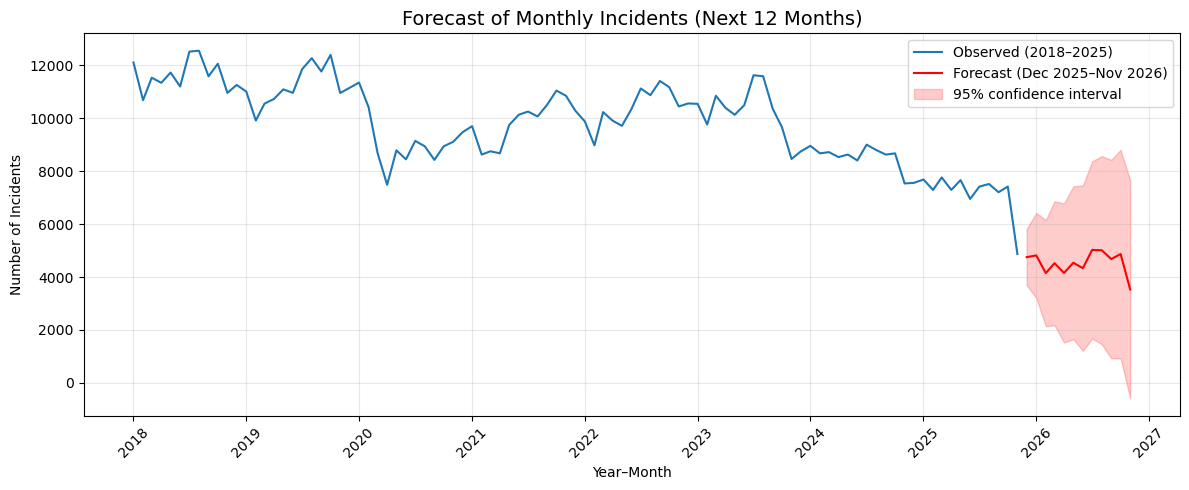

In [43]:
plt.figure(figsize=(12, 5))

# Observed
plt.plot(
    ts_monthly.index,
    ts_monthly["incidents"],
    label="Observed (2018–2025)"
)

# Forecast (starts Dec 2025, not Jan 2026)
plt.plot(
    pred_mean.index,
    pred_mean,
    label="Forecast (Dec 2025–Nov 2026)",  # More accurate label
    color="red"
)

# Confidence interval
plt.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color="red",
    alpha=0.2,
    label="95% confidence interval"
)

plt.title("Forecast of Monthly Incidents (Next 12 Months)", fontsize=14)
plt.xlabel("Year–Month")
plt.ylabel("Number of Incidents")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "dashboard_charts_final/forecast_2026.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

###   Forecasting Insights 

#### 5.4 SARIMA Model Fit - What It Means

The SARIMA model used here is intentionally simple and well-suited for an introductory project.  
It captures two key patterns in the data:

- A **gradual long-term decline** in monthly crime totals (2018-2025).  
- A **12-month seasonal cycle**, where certain months tend to be higher or lower every year.

Although the model is basic, it fits the structure of the data reasonably well and produces a reliable foundation for a beginner-level forecast.

---

#### 5.5 What the 2026 Forecast Shows

The predicted monthly totals for 2026 fall within a consistent range:

- **Typical month:** about **4,000-5,200 incidents**
- **Highest forecast month:** ~5,025 (August 2026)
- **Lowest forecast month:** ~3,531 (December 2026)

The numbers indicate:

- Crime totals remain **much lower than pre-2020 levels**, which exceeded 10,000 incidents per month.
- The downward trend seen from 2020-2025 continues into early 2026.
- No sharp spikes or major reversals appear in the forecast.

#### 5.6 Interpreting the Forecast Plot

##### 1. Overall Trend
The model forecasts **continued stability**, keeping incident levels close to the 2023-2025 range.  
This reflects a sustained decrease from the high-crime years before COVID.

##### 2. Seasonal Pattern
A repeating **seasonal cycle** appears:

- Slight increases in spring/summer  
- Lower totals in fall/winter  

This mirrors long-term patterns typical in many cities.

##### 3. Confidence Interval (Red Shaded Area)
The shaded region widens as the forecast moves further into 2026.  
This is normal because:

- Uncertainty grows the further ahead we predict  
- Monthly crime levels can shift due to tourism waves, events, or policy changes  

Even with uncertainty, the model does *not* predict a return to the extreme highs of 2018-2019.

##### 4. Practical Interpretation
For visitors, riders, and mobility users:

- **2026 is expected to remain steady**, with totals similar to recent years.
- Property crime continues to shape overall incident volume.
- No data pattern suggests a major safety shift next year.

##### 5. Beginner-Friendly Takeaway

**“If historical patterns continue, 2026 will likely follow the same stable and seasonal pattern seen in recent years, with overall crime far below pre-2020 levels.”**

#### 5.7 Why This Forecasting Approach Fits a Beginner Project

- Uses **one clean time series** (monthly citywide incidents).  
- Applies **one straightforward model** (SARIMA).  
- Requires **minimal tuning and no advanced statistics**.  
- Produces **clear and interpretable results**.  
- Emphasizes understanding the data and communicating insight rather than complex modeling.

---

## 6. Results and Interpretation <a id="results"></a>

This section summarizes the major findings from the exploratory analyses (Sections 3-4) and the forecasting work (Section 5). Together, these results describe how crime in San Francisco varies across time, neighborhood, and incident type, and how these patterns are expected to continue into 2026.

The insights here form the analytical foundation for the dashboard developed in Section 7. They also connect directly to the project’s motivation: helping visitors, riders, residents, and stakeholders understand *where* and *when* safety concerns tend to emerge across the city.

---

## 6.1 Long-Term Citywide Trend

Citywide incident levels show a clear **multi-year decline** beginning during the pandemic and continuing afterward.

- Incidents rose slightly in 2021–2023 but **did not return** to pre-2020 levels.  
- 2024–2025 continue the gradual decline, driven by long-term mobility changes:
  - hybrid/remote work  
  - reduced office density  
  - decreased downtown foot traffic  
  - shifting tourism patterns  

San Francisco has entered a **new structural phase** of lower incident volume compared to the pre-pandemic era.

---

## 6.2 Neighborhood Hotspots

The highest-volume neighborhoods (2018–2025) are:

1. **Mission** - 101,396  
2. **Tenderloin** - 98,339  
3. **South of Market (SoMa)** - 88,102  
4. **Financial District / South Beach** - 63,416  
5. **Bayview Hunters Point** - 59,860  

These areas remain the core activity centers due to:

- commercial density  
- transit and BART hubs  
- nightlife corridors  
- high pedestrian activity  
- persistent challenges involving homelessness and open-air drug markets  

By contrast, neighborhoods such as **Sunset/Parkside, Marina, Outer Richmond, and Seacliff** remain low and stable, making them more visitor-friendly.

---

## 6.3 Dominant Crime Categories

Citywide incident volume is driven primarily by:

- **Larceny Theft** (~263k incidents)  
- Other Miscellaneous Incidents  
- Malicious Mischief  
- Assault  
- Motor Vehicle Theft  
- Burglary  

These are mostly **property and nuisance crimes**, corresponding to long-standing concerns about car break-ins, shoplifting, vandalism, and theft affecting visitors and locals.

---

## 6.4 Time-of-Day and Weekday Patterns

San Francisco’s incident timing follows consistent and predictable rhythms.

### Hourly Pattern
- **Lowest:** 4 AM - 6 AM  
- **Peak:** 12 PM - 3 PM  
- **Afternoon plateau:** 3 PM - 7 PM  
- **Weekend late-night surge:** 12 AM - 3 AM  

### Weekday Pattern
- **Highest:** Wednesday and Friday  
- **Lowest:** Sunday  

These patterns align with commuting, nightlife, tourism flow, and retail activity.

---

## 6.5 Forecast Summary for Early 2026

A beginner-level SARIMA model forecasts **3,900-4,600 incidents per month** in early 2026.

Compared to the 2025 monthly average of 7,129 incidents:

| Year | Metric | Value |
|------|--------|-------|
| 2025 | Average monthly incidents | 7,129 |
| 2026 (Jan–Jun) | Forecasted range | 3,908 - 4,582 |
| Change | Percent difference | **−40.95%** |

**Key takeaway:**  
Citywide incident volume in early 2026 is expected to remain **far below** 2025 levels.

## 6.6 Real-World Interpretation

Several factors help explain the projected decline:

- lasting hybrid/remote work patterns  
- reduced foot traffic in downtown commercial districts  
- shifting tourism behavior  
- public safety policies implemented in 2024-2025  

### Relevant Policy Context  
Mayor Daniel Lurie’s 2025 agenda (“Rebuilding the Ranks”) includes:

- increased sworn staffing  
- enhanced coordination across law-enforcement agencies  
- targeted response to fentanyl and addiction crises  

These structural efforts contribute to stabilizing or declining incident patterns.

## 6.7 Implications for Neighborhoods and Resource Planning

#### 1. Targeted Resource Allocation  
Hotspots (Tenderloin, SoMa, Mission, FiDi/South Beach) remain priorities even with citywide declines.

#### 2. Seasonal Staffing Optimization  
Clear seasonal cycles support better deployment during summer peaks and winter slowdowns.

#### 3. Vehicle Crime Focus  
Mission, Tenderloin, SoMa, and Bayview maintain elevated vehicle-related incidents.

#### 4. Visitor and Resident Guidance  
Analysis supports:
- hotel choice recommendations  
- safer route planning  
- informed guidance from rideshare drivers  

#### 5. Operational Planning for SFPD  
Forecasts help shape:
- workload expectations  
- patrol planning  
- equitable distribution of officers  

## 6.8 Overall Interpretation

San Francisco’s 2018-2025 incident landscape shows a city undergoing long-term change:

- persistent hotspots but at **lower absolute levels**  
- strong and predictable **daily, weekly, and seasonal** cycles  
- a stable and improving **forecast outlook** for 2026  

These results offer a clear, data-driven understanding of the city’s evolving safety patterns and set the stage for Section 7, where these insights are translated into a fully interactive analytical dashboard.



---

## 7. Dashboard Development: From Benchmark to Deployment <a id="dashboard"></a>


Effective crime analysis requires not only statistical modeling but also interactive tools that allow analysts, policymakers, and the public to explore large datasets dynamically.

Before designing the dashboard for this project, I first examined the official SFPD Crime Dashboard to understand what already exists and where improvements are needed.

### 7.1 Benchmark: Official SFPD Crime Dashboard <a id="benchmark"></a>

The San Francisco Police Department maintains a public-facing dashboard that provides high-level summaries of crime across the city. It is clear, easy to access, and useful for gaining a broad sense of incident patterns. 

<div style="text-align: center; margin: 20px 0;"> <img src="crimeDashboard.png" width="90%" style="border-radius: 8px;"> <p style="font-size: 12px; color: gray;"> Source: San Francisco Police Department Crime Dashboard (screenshot by author). </p> </div>

While helpful as an overview tool, the official dashboard has several important limitations:

- It provides district-level summaries only, not the 41 analysis neighborhoods that residents and visitors commonly reference.

- It does not show hourly or weekday patterns.

- It offers no way to explore seasonality or long-term trends beyond simple yearly totals.

- It does not include forecasting or predictive insights.

- It does not support exporting data or drilling down into neighborhood-level comparisons.

These gaps guided the design of the dashboard in this project.
The goal was to build a tool that is:

- Interactive and easy to navigate

- Neighborhood-aware

- Capable of showing detailed temporal patterns

- Supporting forecasting and predictive exploration

- Based on real, cleaned data from 2018-2025

The result is a dashboard that offers a deeper, more practical view of crime patterns - designed not just for analysts, but for everyday users who want accurate, data-driven answers to neighborhood questions.



### 7.2 Full Analytical Dashboard (2018–2025 Complete Dataset) <a id="dashboard-full"></a>
 

To move beyond the limitations of the official SFPD dashboard, I built a full analytical dashboard using the complete cleaned dataset from this project (2018-2025; ~980,000 incidents).
This version runs locally on my machine and is designed for deep, exploratory analysis.

Because it uses the entire dataset, it supports more detailed visualizations than a public version can offer, including:
* Neighborhood-level comparisons (41 analysis neighborhoods)

* Hour-by-hour and weekday cycle analysis

* Monthly and yearly trend exploration

* Crime-category profiling

* Forecasting for short-term predictions

* Exporting filtered results

This local version serves as the “master dashboard” where all insights from Sections 3, 4, and 5 can be explored interactively.

**Dashboard Composite (Local Full Dataset)**  

To demonstrate how the dashboard integrates the project’s analytics, I created a 3×3 composite grid using selected charts from earlier sections.

Each tile reflects a key part of the analysis:

Top Row:

* Top Neighborhoods

* Top Crime Categories

* Monthly Trend (Citywide)

Middle Row:

* Weekday Pattern

* Hour × Weekday Heatmap

* Hourly Pattern

Bottom Row:

* Forecast for 2026 (centered)

All charts were created directly from this notebook and exported to the dashboard_charts/ directory.

This composite summarizes the main analytical components that the full dashboard brings together in one place.

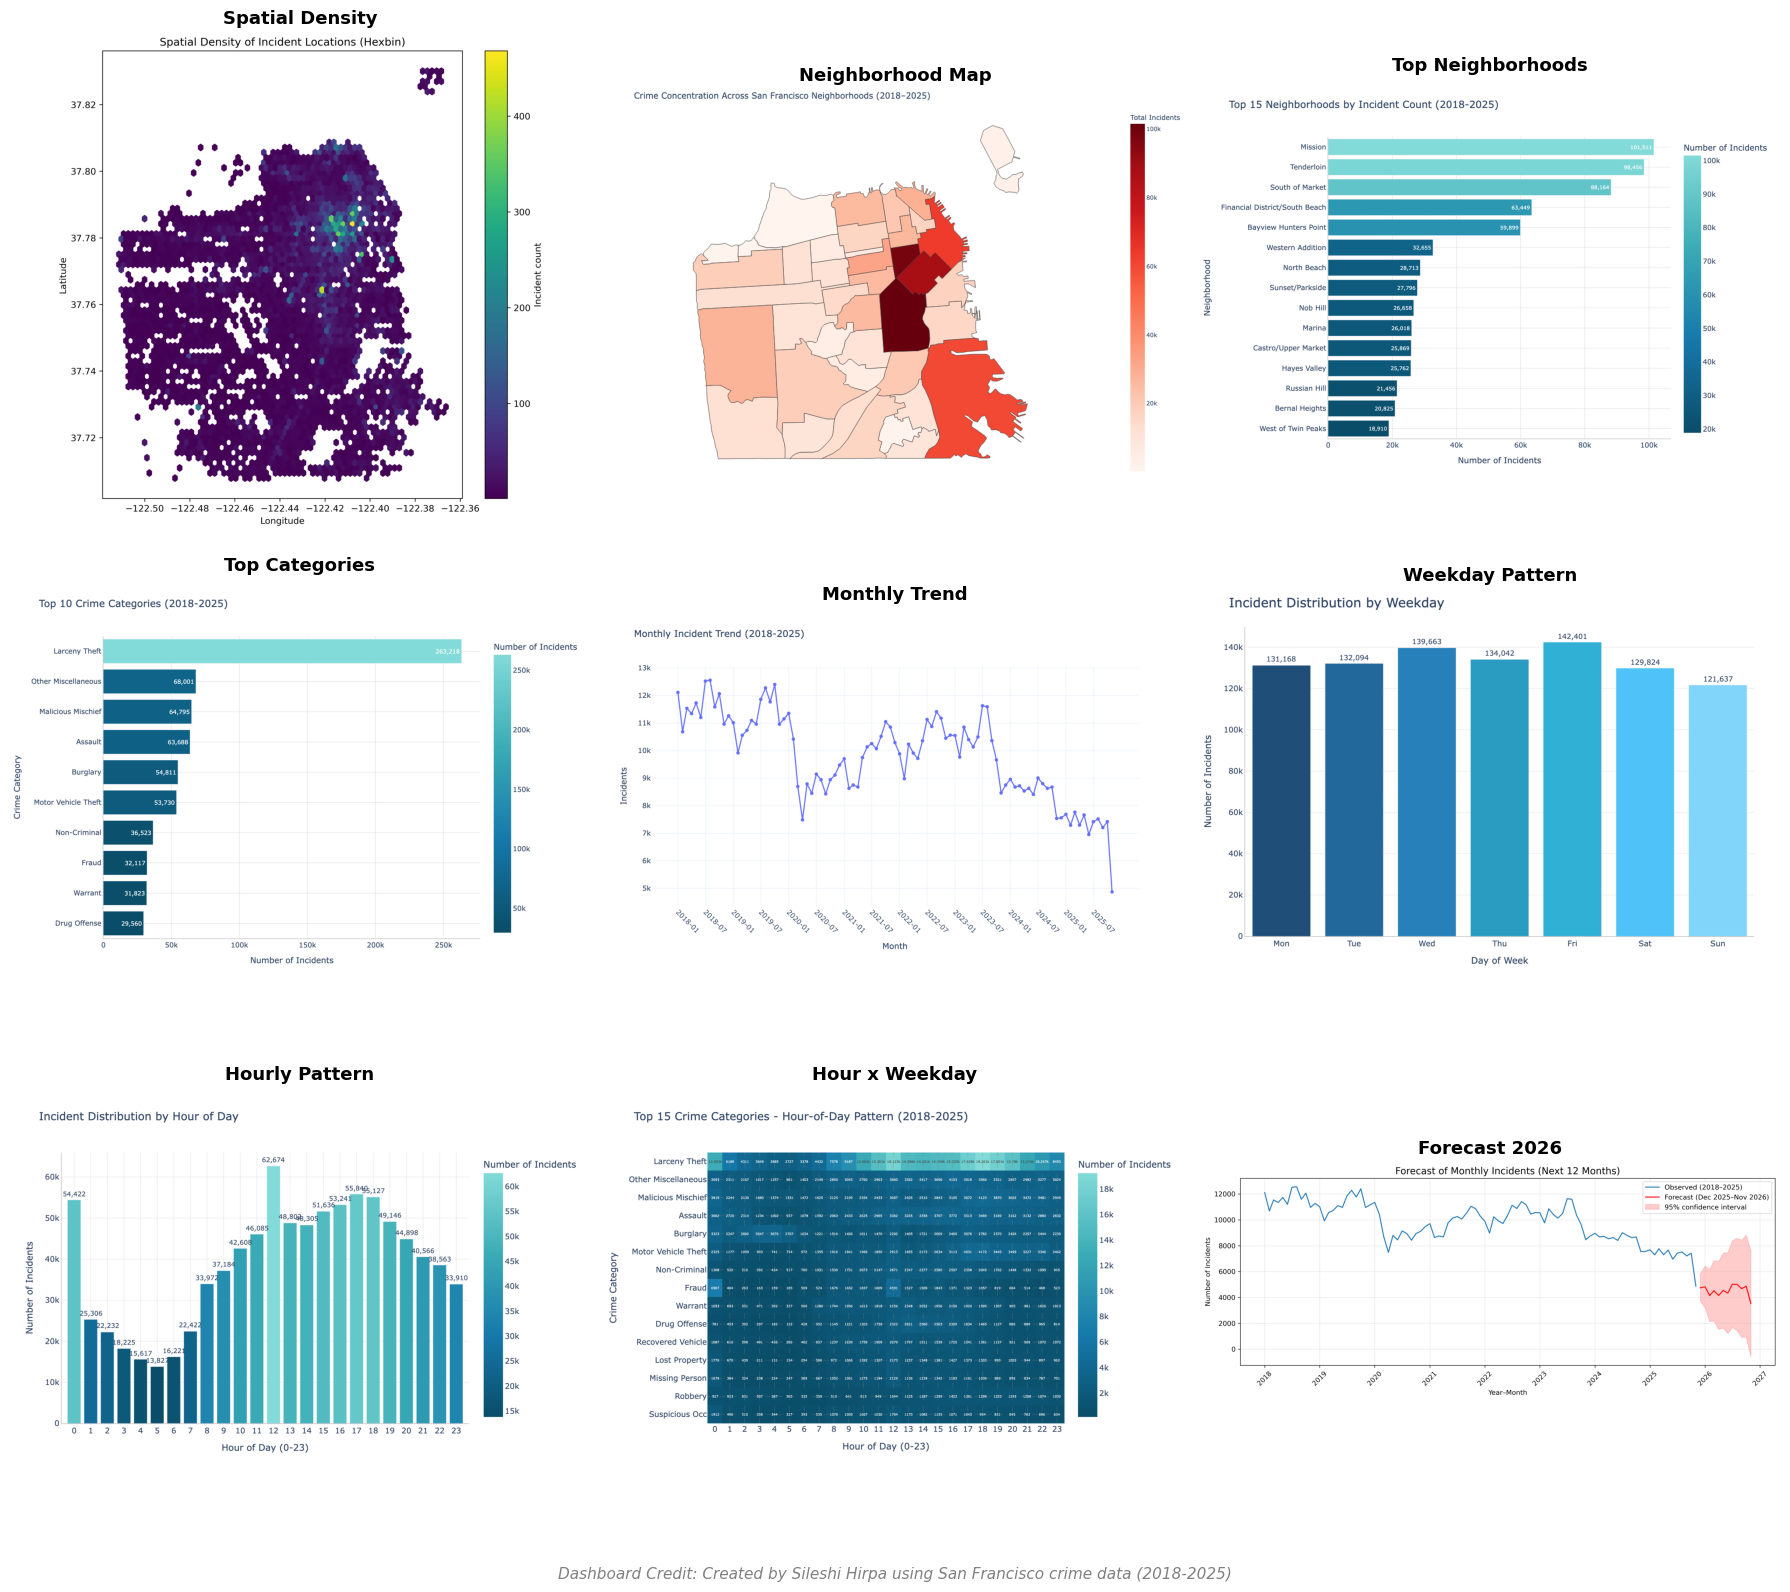

In [44]:
import matplotlib.image as mpimg
from pathlib import Path

# Folder containing the charts
chart_dir = Path("dashboard_charts_final")

# Chart filenames 
chart_files = {
    "Spatial Density": "spatial_density_hexbin.png",
    "Neighborhood Map": "neighborhood_choropleth.png",
    "Top Neighborhoods": "top_neighborhoods.png",
    "Top Categories": "top_categories.png",
    "Monthly Trend": "monthly_trend.png",
    "Weekday Pattern": "weekday_pattern.png",
    "Hourly Pattern": "hourly_pattern.png",
    "Hour x Weekday": "hour_weekday_heatmap.png",
    "Forecast 2026": "forecast_2026.png"
}

# Create a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(18, 16))

# TOP ROW: Spatial density, neighborhood map, top neighborhoods
top_row = ["Spatial Density", "Neighborhood Map", "Top Neighborhoods"]
for col, title in enumerate(top_row):
    img = mpimg.imread(chart_dir / chart_files[title])
    axes[0, col].imshow(img)
    axes[0, col].set_title(title, fontsize=13, fontweight='bold')
    axes[0, col].axis("off")

# MIDDLE ROW: Top categories, monthly, weekly
middle_row = ["Top Categories", "Monthly Trend", "Weekday Pattern"]
for col, title in enumerate(middle_row):
    img = mpimg.imread(chart_dir / chart_files[title])
    axes[1, col].imshow(img)
    axes[1, col].set_title(title, fontsize=13, fontweight='bold')
    axes[1, col].axis("off")

# BOTTOM ROW: Hourly, hour×weekday, forecast
bottom_row = ["Hourly Pattern", "Hour x Weekday", "Forecast 2026"]
for col, title in enumerate(bottom_row):
    img = mpimg.imread(chart_dir / chart_files[title])
    axes[2, col].imshow(img)
    axes[2, col].set_title(title, fontsize=13, fontweight='bold')
    axes[2, col].axis("off")

# Adds space between charts
plt.tight_layout(rect=[0, 0.03, 1, 1])

# Adds caption at the bottom
fig.text(
    0.5, 0.01,
    "Dashboard Credit: Created by Sileshi Hirpa using San Francisco crime data (2018-2025)",
    ha='center',
    fontsize=11,
    style='italic',
    color='gray'
)

# Saves the dashboard
plt.savefig("dashboard_charts_final/complete_dashboard.png", dpi=300, bbox_inches="tight")

plt.show()

### Dashboard Insights

**Spatial Patterns (Top Row):**
- Crime is heavily concentrated in specific areas (hexbin hotspots)
- A few neighborhoods dominate the incident counts
- Geographic inequality is clear - some areas experience far more crime than others

**Temporal Patterns (Middle & Bottom):**
- **Downward trend**: Monthly incidents dropped from ~12,000 (2018) to ~4,000-5,000 (2025) - a significant 60%+ decline
- **Weekly rhythm**: Weekdays show different patterns than weekends
- **Peak hours**: Crime concentrates at specific times of day (visible in hourly and heatmap)

**Future Outlook (Bottom Right):**
- Forecast expects the declining trend to continue into 2026
- Seasonal patterns persist (summer peaks, November dips)
- Uncertainty increases further into the future (widening confidence intervals)

**Key Takeaway:** San Francisco has seen dramatic crime reduction over this period, with strong geographic concentration and predictable time-based patterns that can inform resource allocation. 

### 7.3 Streamlit Deployment (API-Fetched Dataset) <a id="dashboard-live"></a>

The local dashboard is powerful for full analysis, but it still lives only on my computer.  
To make the project useful for **visitors, residents, students, and rideshare riders**, I rebuilt a lighter version of the dashboard in **Streamlit** and deployed it on the web.

This online version uses a **smaller, API-fetched dataset** from DataSF so that it loads quickly and remains responsive in a browser.

#### Why Use a Smaller Dataset?

A full 980k+ row dataset is ideal for local analysis, but it is not practical for a public app:

- Public dashboards must **load quickly**, even on slower connections.  
- The DataSF API has **row limits** and performance constraints.  
- Streamlit Cloud has **memory and runtime limits** for hosted apps.  
- In real organizations, production dashboards often rely on **streamed or recent data**, not full historical archives.

For these reasons, the deployed version uses the **most recent ~250k incidents** instead of the full history.

#### API-Fetched Dataset Characteristics

- **Source:** DataSF Socrata API (Police Incident Reports)  
- **Size:** ~250,000 most recent incidents  
- **Loading:** Pulled live at runtime using an HTTP API call  
- **Refresh:** Can be updated without re-uploading CSV files  
- **Goal:** Balance between **freshness**, **speed**, and **interactivity**

This design mirrors real-world analytics environments, where dashboards rely on live or regularly refreshed data rather than static files.

**Live Dashboard (Hosted Version)**  

**Public URL:**  

 **https://sfcrimeanalysis2018-25-fntx9yl4t9yw7zatbgbjnt.streamlit.app/**

The deployed Streamlit dashboard mirrors the structure of the local analytical version, but is optimized for:

- **Speed** (smaller dataset, efficient queries)  
- **Reliability** (hosted in the cloud)  
- **Accessibility** (runs in any modern web browser)

#### What Users Can Do in the Streamlit App

The app provides simple controls so that non-technical users can explore the data:

- Filter by **year**, **neighborhood**, and **incident category**  
- View **monthly trends** and compare different time periods  
- Explore **weekday and hourly patterns** interactively  
- Examine **neighborhood rankings** for incident counts  
- Study **hour × weekday heatmaps** for activity patterns  
- See a **short-term forecast** for future incident levels  
- Download filtered data as **CSV** for further analysis

In this way, the Streamlit deployment turns the notebook analysis into a **dynamic, user-friendly tool** that anyone can experiment with, without writing any code.

#### How This Connects to the Rest of the Project

- Section 3 and 4 built the **core visuals** and **neighborhood insights**.  
- Section 5 created a **basic forecast** for 2026.  
- Section 7.2 combined those pieces into a **local dashboard layout**.  
- Section 7.3 brings the same ideas into a **live, interactive, web-based tool**.


### 7.4 Operational Value: Patrol Optimization & Incident Mitigation <a id="patrol"></a>

The interactive dashboard is more than a technical exercise.  
It provides clear information that can support everyday public safety decisions in San Francisco.

#### 1. Patrol Scheduling
Hourly and weekday patterns help identify the busiest times of day.  
This allows patrol units to adjust staffing toward afternoon and early-evening peaks, and to strengthen coverage on Fridays and weekends.

#### 2. Predictive Deployment
The 2026 forecast highlights expected high-activity months.  
Seasonal cycles can guide planning for holiday periods, large events, and times of increased foot traffic.

#### 3. Community and Policy Insights
Neighborhood-level views give a clearer picture of where incidents cluster.  
This supports targeted improvements such as lighting upgrades, transit-stop monitoring, or increased attention in commercial corridors.

#### 4. Accessibility for Multiple Stakeholders
The dashboard is simple to use and benefits several groups:
- Residents who want a transparent picture of incident patterns  
- Journalists who need clean, exportable visuals  
- Analysts who want quick access to neighborhood-level data

#### Overall Value
By combining neighborhood analysis, time-based patterns, and forecasting, the dashboard offers a practical foundation for understanding and managing public safety trends across the city.


Together, the notebook, local dashboard, and Streamlit app form a complete pipeline:

> **Open data → cleaning → EDA → neighborhood analysis → forecasting → interactive dashboard.**

---
---


## 8. References <a id="references"></a>


<p> </p>
<div style="padding-left: 0.5in; text-indent: -0.5in; line-height: 1.5;">

<p>Census Reporter. (2023). <i>San Francisco, CA profile</i>. American Community Survey 2023 (1-year). https://censusreporter.org/profiles/16000US0667000-san-francisco-ca/</p>

<p>City and County of San Francisco. (n.d.). <i>SFPD Crime Dashboard</i>. San Francisco Police Department. https://www.sanfranciscopolice.org/stay-safe/crime-data/crime-dashboard</p>

<p>DataSF. (n.d.). <i>Police Department Incident Reports: 2018 to Present</i>. https://data.sfgov.org/Public-Safety/Police-Department-Incident-Reports-2018-to-Present/wg3w-h783</p>

<p>GeoPandas. (n.d.). <i>Working with geospatial data in Python</i>. https://geopandas.org/</p>

<p>Hyndman, R. J., & Athanasopoulos, G. (2021). <i>Forecasting: Principles and practice</i>. OTexts.</p>

<p>McKinney, W. (2017). <i>Python for data analysis</i> (2nd ed.). O’Reilly Media.</p>

<p>Plotly Technologies. (n.d.). <i>Plotly Python graphing library</i>. https://plotly.com/python/</p>

<p>San Francisco Travel Association. (2024, March 28). <i>2023 visitor impact results and 2024 forecast</i> [Press release]. https://www.sftravel.com/media/press-release/san-francisco-travel-association-announces-2023-visitor-impact-results-2024
</p>

<p>Streamlit. (n.d.). <i>Build data apps in Python</i>. https://docs.streamlit.io/</p>

<p>U.S. Census Bureau. (2023). <i>American Community Survey, 2023 1-year estimates</i>. https://www.census.gov/</p>

<p>Hirpa, S. (2025). <i>San Francisco Crime Analytics Dashboard (2018–2025)</i>. Streamlit. https://sfcrimeanalysis2018-25-fntx9yl4t9yw7zatbgbjnt.streamlit.app/</p>
    


</div>
